In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [4]:
# Load your dataset into a pandas DataFrame
df = pd.read_excel(r'C:\Users\aravi\Downloads\Research papers youtube\Dataset\Casey Neistat_statistics - New.xlsx')  


In [5]:
df.isna().sum()

Video ID                       0
Views                          0
Likes                          0
Comments                       0
Duration                       0
Duration (Seconds)             0
Tags                         843
Tag (Yes=1, No=0)              0
Category                       0
Category Name                  0
Published At                   0
Likes (Z score)                0
Comments Z score)              0
Views (Zscore)                 0
Duration Z score               0
Published Date                 0
Time of the Day                0
Published Time                 0
Hour                           0
Engagement Score(chumma)       0
Engagement Score               0
Unnamed: 21                 1088
Unnamed: 22                 1078
Unnamed: 23                 1090
dtype: int64

In [6]:
df.columns

Index(['Video ID', 'Views', 'Likes', 'Comments', 'Duration',
       'Duration (Seconds)', 'Tags', 'Tag (Yes=1, No=0)', 'Category',
       'Category Name', 'Published At', 'Likes (Z score)', 'Comments Z score)',
       'Views (Zscore)', 'Duration Z score', 'Published Date',
       'Time of the Day', 'Published Time', 'Hour', 'Engagement Score(chumma)',
       'Engagement Score', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23'],
      dtype='object')

In [7]:
df=df[['Video ID', 'Views', 'Likes', 'Comments',
       'Duration (Seconds)',  'Tag (Yes=1, No=0)',
       'Category Name', 'Published Date','Published At',
       'Time of the Day', 'Published Time',
       'Engagement Score']]

In [8]:
df.isna().sum()

Video ID              0
Views                 0
Likes                 0
Comments              0
Duration (Seconds)    0
Tag (Yes=1, No=0)     0
Category Name         0
Published Date        0
Published At          0
Time of the Day       0
Published Time        0
Engagement Score      0
dtype: int64

In [21]:
# Assuming you have a DataFrame 'df'

# Convert the 'Tag (Yes=1, No=0)' column to a categorical variable
df['Tag (Yes=1, No=0)'] = df['Tag (Yes=1, No=0)'].astype('category')

# Verify the data type change
print(df.dtypes)


Video ID                      object
Views                          int64
Likes                          int64
Comments                       int64
Duration (Seconds)             int64
Tag (Yes=1, No=0)           category
Category Name                 object
Published Date        datetime64[ns]
Published At                  object
Time of the Day               object
Published Time                object
Engagement Score             float64
dtype: object


In [22]:
# Display summary statistics of numeric columns
print(df.describe())


              Views         Likes       Comments  Duration (Seconds)  \
count  1.100000e+03  1.100000e+03    1100.000000         1100.000000   
mean   2.866041e+06  7.674883e+04    6071.305455          493.528182   
std    4.052141e+06  7.903336e+04   16112.121927          174.026355   
min    1.470720e+05  2.025000e+03     117.000000           28.000000   
25%    1.381321e+06  3.781050e+04    2334.250000          407.750000   
50%    2.031741e+06  6.233700e+04    4117.500000          496.000000   
75%    3.099148e+06  9.025375e+04    6285.250000          590.000000   
max    7.882453e+07  1.106300e+06  400184.000000         2122.000000   

       Engagement Score  
count       1100.000000  
mean           0.062654  
std            0.055962  
min            0.000000  
25%            0.038820  
50%            0.052134  
75%            0.070384  
max            1.000000  


In [23]:
# Frequency distribution for Video category
category_counts = df['Category Name'].value_counts()

# Frequency distribution for Publishing time
time_counts = df['Time of the Day'].value_counts()
tag_counts = df['Tag (Yes=1, No=0)'].value_counts()

In [25]:
category_counts, time_counts, tag_counts


(People & Blogs           862
 Travel & Events          176
 Howto & Style             19
 Nonprofits & Activism     11
 Science & Technology       7
 Autos & Vehicles           7
 Sports                     6
 Pets & Animals             5
 Education                  4
 Film & Animation           2
 Music                      1
 Name: Category Name, dtype: int64,
 Afternoon        689
 Evening          203
 Night            169
 Morning           37
 Early Morning      2
 Name: Time of the Day, dtype: int64,
 0    843
 1    257
 Name: Tag (Yes=1, No=0), dtype: int64)

In [20]:
time_counts

Afternoon        689
Evening          203
Night            169
Morning           37
Early Morning      2
Name: Time of the Day, dtype: int64

In [24]:
tag_counts

0    843
1    257
Name: Tag (Yes=1, No=0), dtype: int64

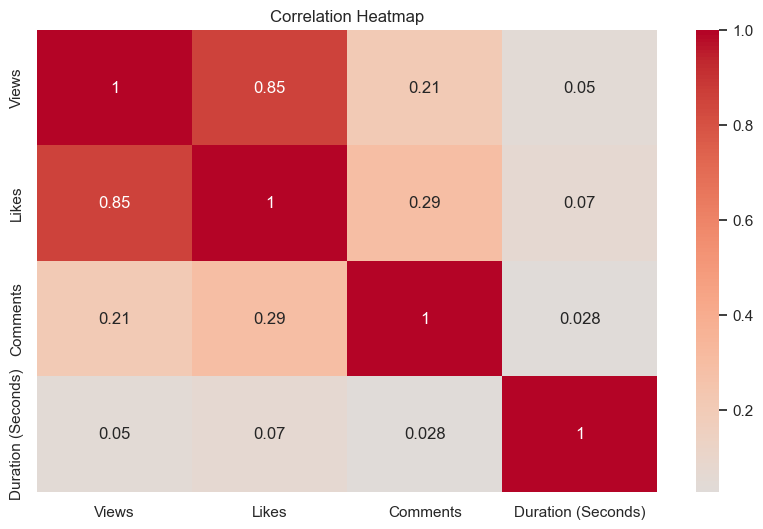

In [70]:
# Compute correlation matrix
correlation_matrix = df[['Views', 'Likes', 'Comments', 'Duration (Seconds)']].corr()

# Create a heatmap to visualize correlations
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


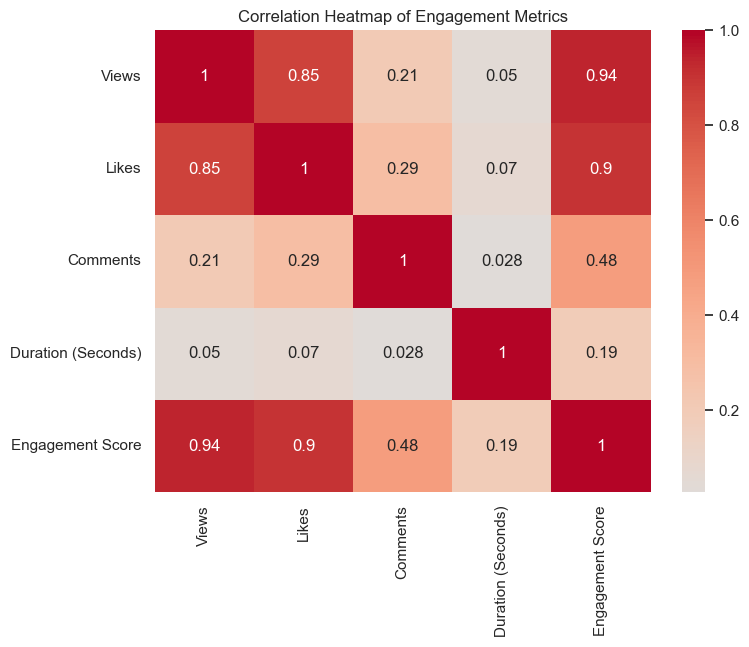

In [71]:
# Calculate correlation matrix
correlation_matrix = df[['Views', 'Likes', 'Comments', 'Duration (Seconds)', 'Engagement Score']].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Engagement Metrics')
plt.show()

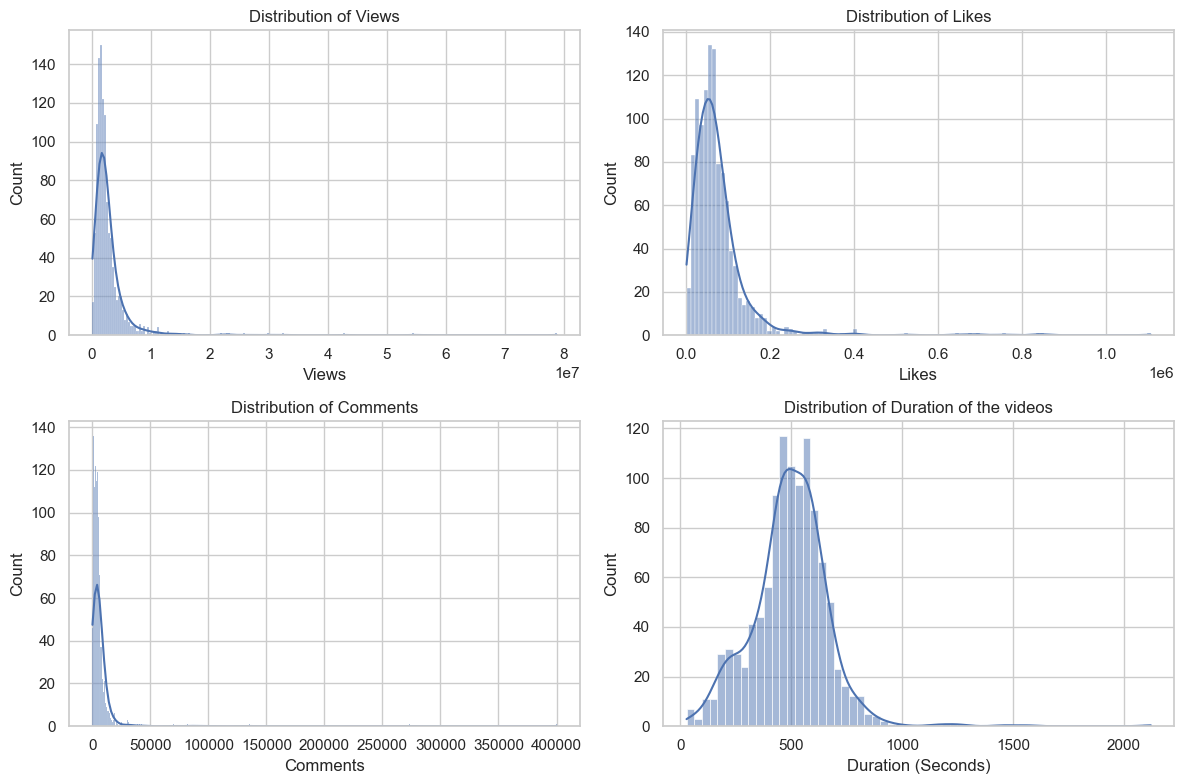

In [72]:
# Plot histograms of engagement metrics
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(data=df, x='Views', kde=True)
plt.title('Distribution of Views')

plt.subplot(2, 2, 2)
sns.histplot(data=df, x='Likes', kde=True)
plt.title('Distribution of Likes')

plt.subplot(2, 2, 3)
sns.histplot(data=df, x='Comments', kde=True)
plt.title('Distribution of Comments')

plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Duration (Seconds)', kde=True)
plt.title('Distribution of Duration of the videos')



plt.tight_layout()
plt.show()


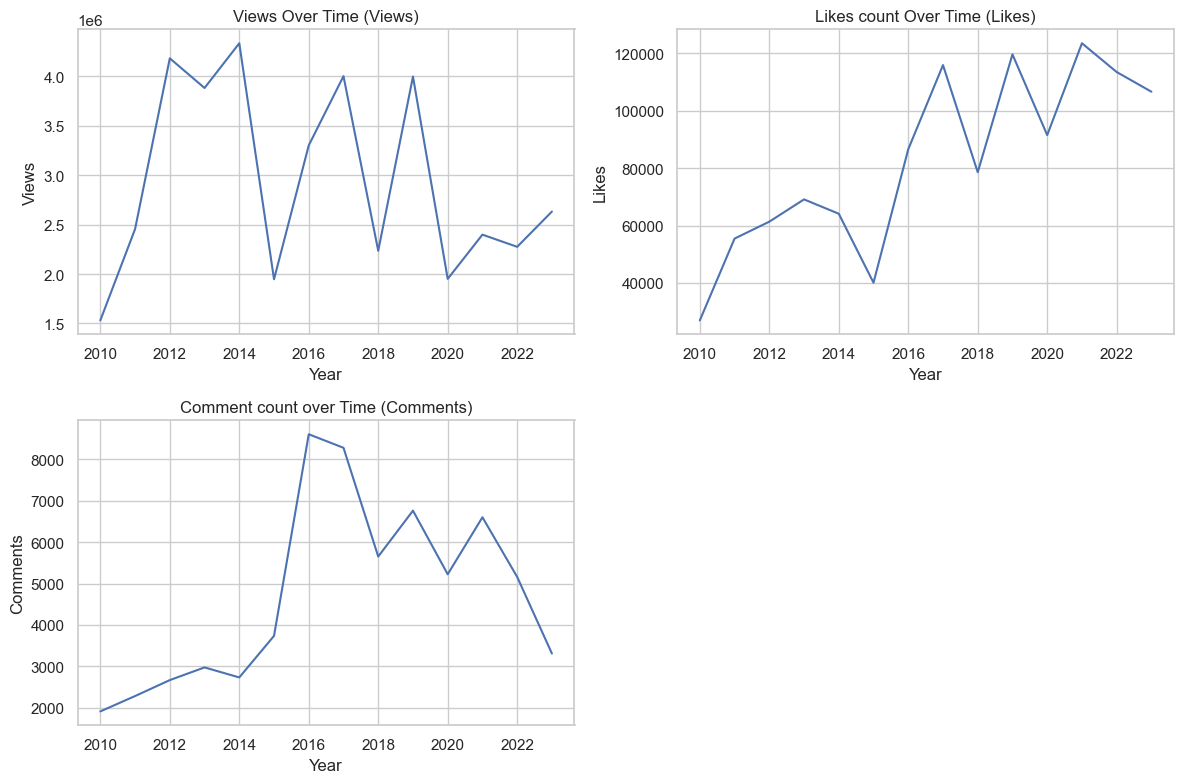

In [73]:
# Convert 'Published At' to datetime
df['Published At'] = pd.to_datetime(df['Published At'])

# Extract year and month
df['Year'] = df['Published At'].dt.year
df['Month'] = df['Published At'].dt.month

# Group by year and month and plot engagement metrics over time
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.lineplot(data=df, x='Year', y='Views', ci=None)
plt.title('Views Over Time (Views)')

plt.subplot(2, 2, 2)
sns.lineplot(data=df, x='Year', y='Likes', ci=None)
plt.title('Likes count Over Time (Likes)')

plt.subplot(2, 2, 3)
sns.lineplot(data=df, x='Year', y='Comments', ci=None)
plt.title('Comment count over Time (Comments)')


plt.tight_layout()
plt.show()


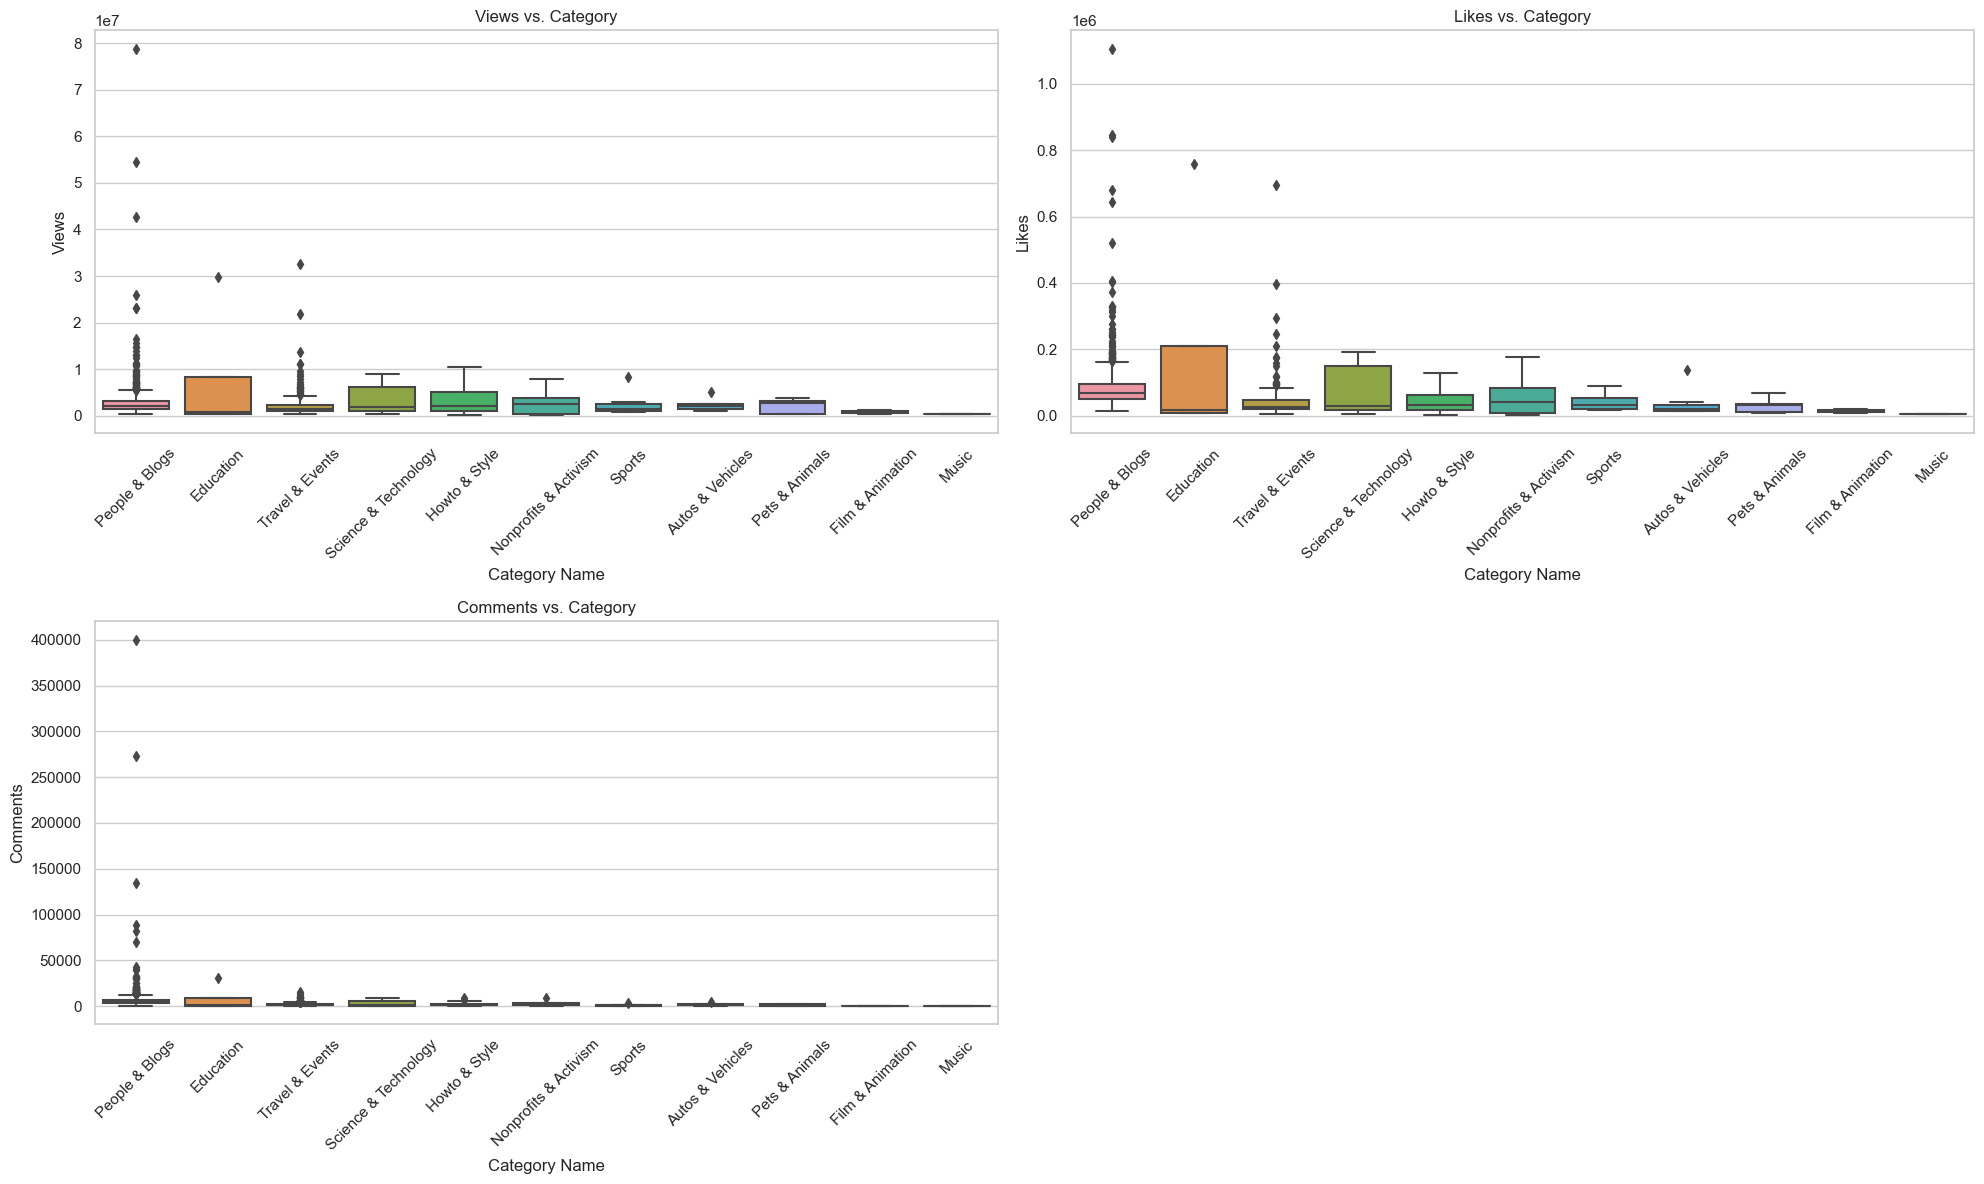

In [74]:
# Boxplot of engagement metrics by category
plt.figure(figsize=(20,12))  # Increase the figsize


plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Category Name', y='Views')
plt.xticks(rotation=45)
plt.title('Views vs. Category')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Category Name', y='Likes')
plt.xticks(rotation=45)
plt.title('Likes vs. Category')

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Category Name', y='Comments')
plt.xticks(rotation=45)
plt.title('Comments vs. Category')

# Add more subplots as needed

plt.subplots_adjust(hspace=0.4)  # Adjust vertical spacing between subplots

plt.tight_layout()
plt.show()


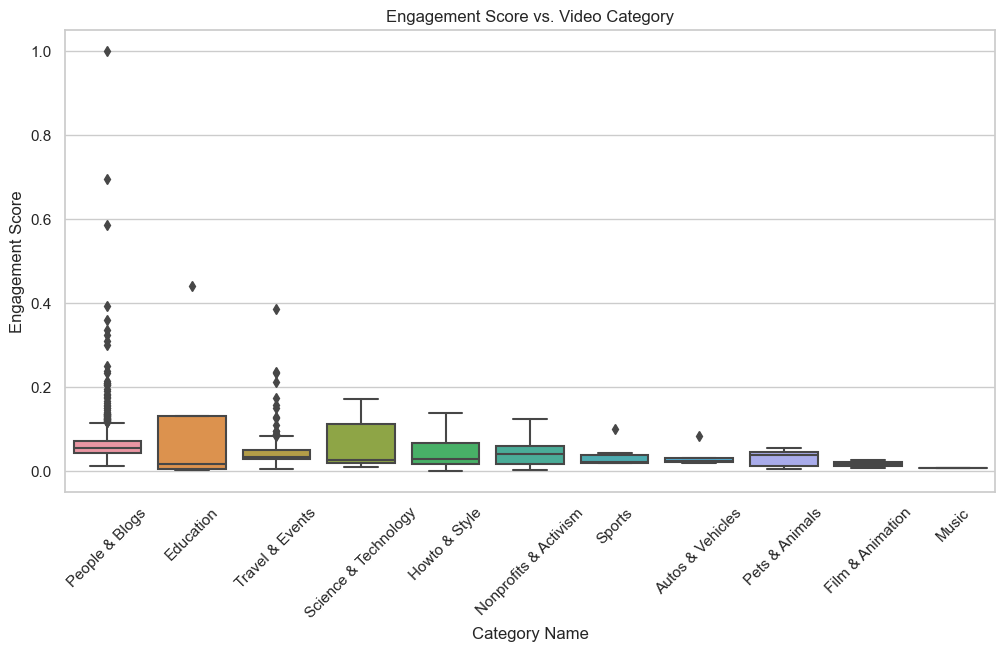

In [75]:

# Boxplot for Engagement Metrics and Engagement Score vs. Category
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category Name', y='Engagement Score', data=df)
plt.xticks(rotation=45)
plt.title('Engagement Score vs. Video Category')
plt.show()


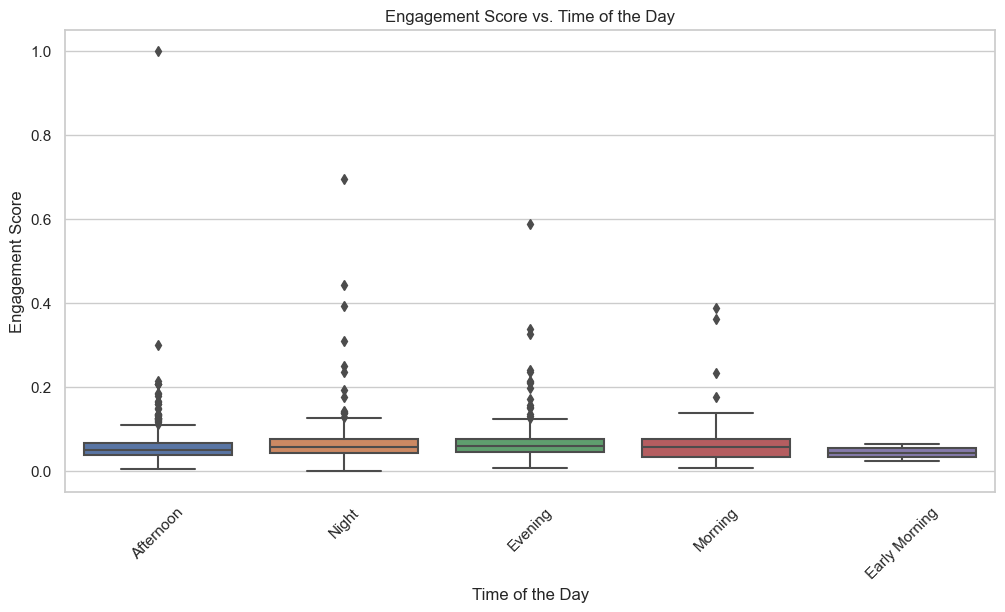

In [76]:
# Assuming you have a column 'Time of Day' with the categorical time categories

# Boxplot for Engagement Metrics and Engagement Score vs. Time of Day
plt.figure(figsize=(12, 6))
sns.boxplot(x='Time of the Day', y='Engagement Score', data=df)
plt.xticks(rotation=45)
plt.title('Engagement Score vs. Time of the Day')
plt.show()



<AxesSubplot:xlabel='Category Name'>

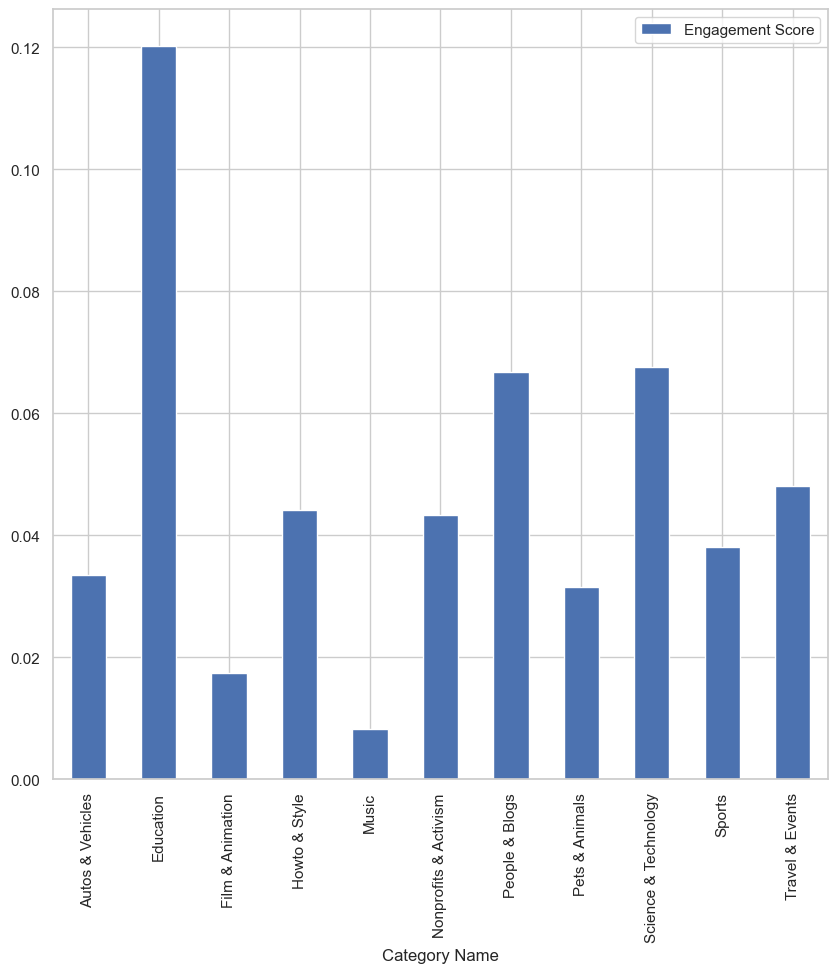

In [77]:
pd.pivot_table(data=df,index='Category Name',values='Engagement Score',aggfunc='mean').plot(kind='bar',figsize=[10,10])

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set the style of seaborn
sns.set(style="whitegrid")

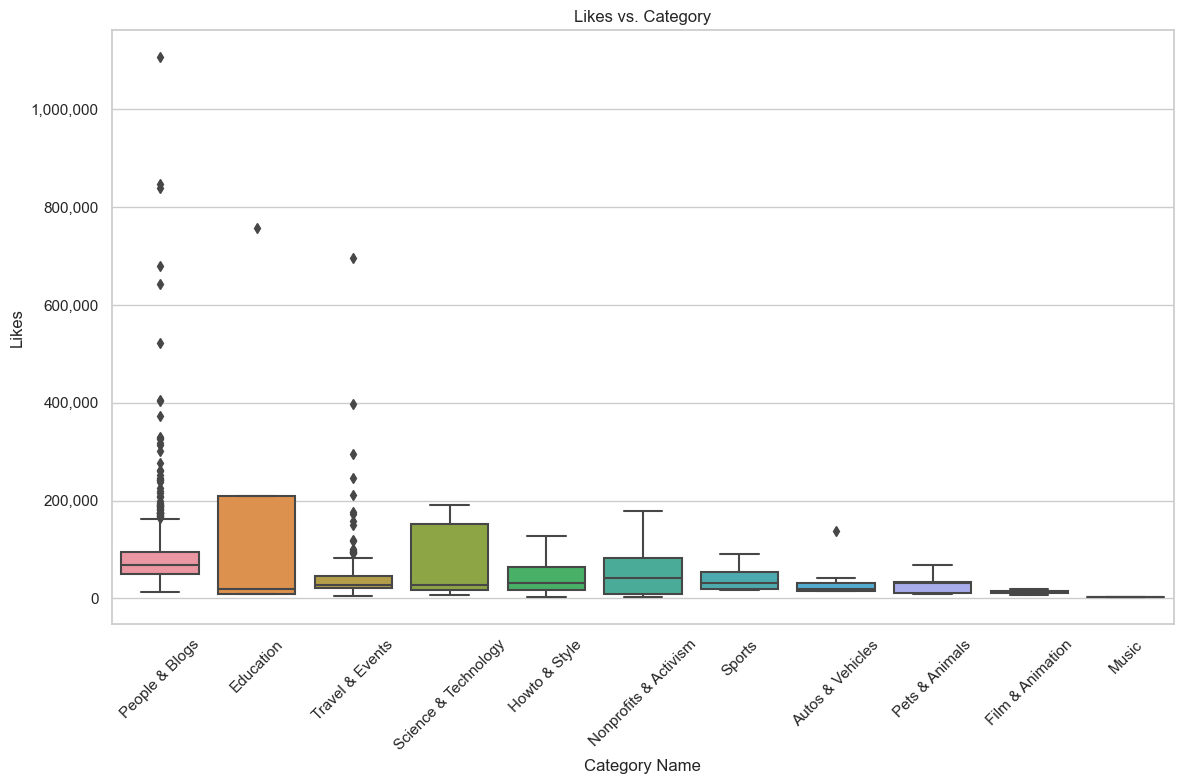

In [80]:
# Boxplot of numerical variables by Category Name
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Category Name', y='Likes').yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.title('Likes vs. Category')
plt.xticks(rotation=45)
plt.tight_layout()
# Format y-axis tick labels to display full numbers


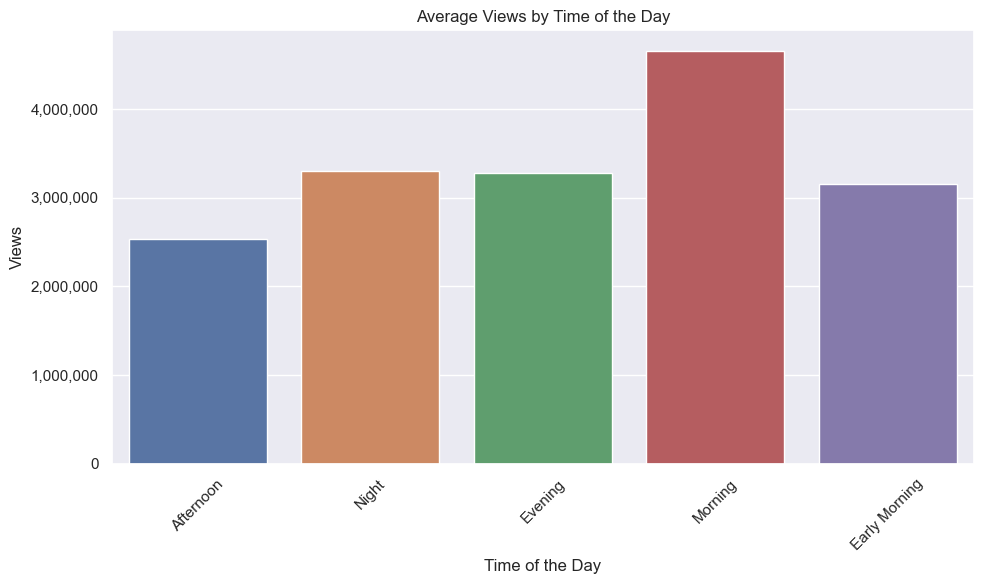

In [81]:
# Bar plot of average numerical variables by Time of the Day
sns.set(style="darkgrid")
import matplotlib.ticker as ticker
# Create a bar plot of average views by time of the day
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, x='Time of the Day', y='Views', ci=None)  # Disable confidence intervals
ax.set_title('Average Views by Time of the Day')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)  # Rotate x-axis labels for better readability

# Format y-axis tick labels to display full numbers
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

plt.tight_layout()
plt.show()

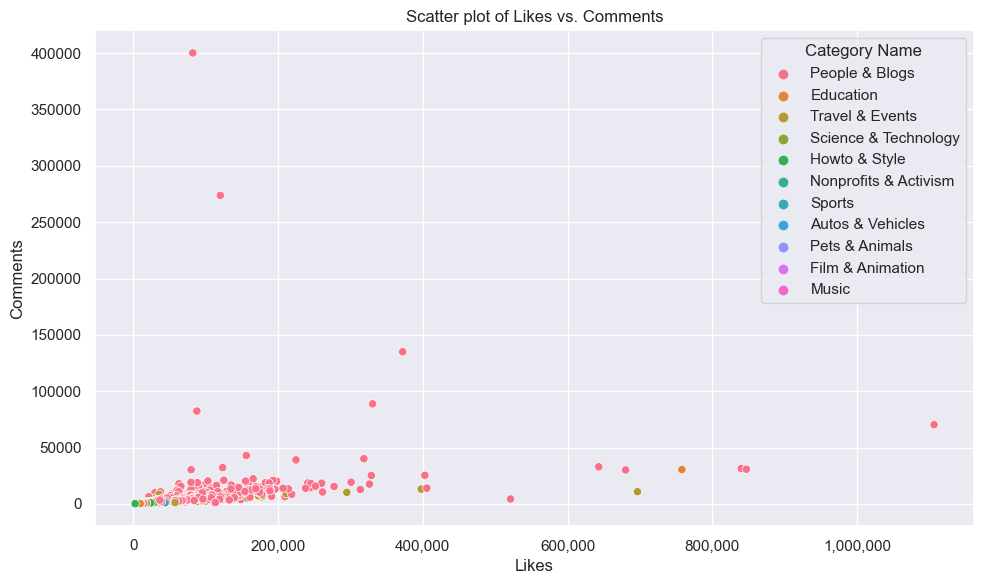

In [82]:
# Scatter plot of numerical variables with hue based on Category Name
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Likes', y='Comments', hue='Category Name').xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.title('Scatter plot of Likes vs. Comments')
plt.tight_layout()

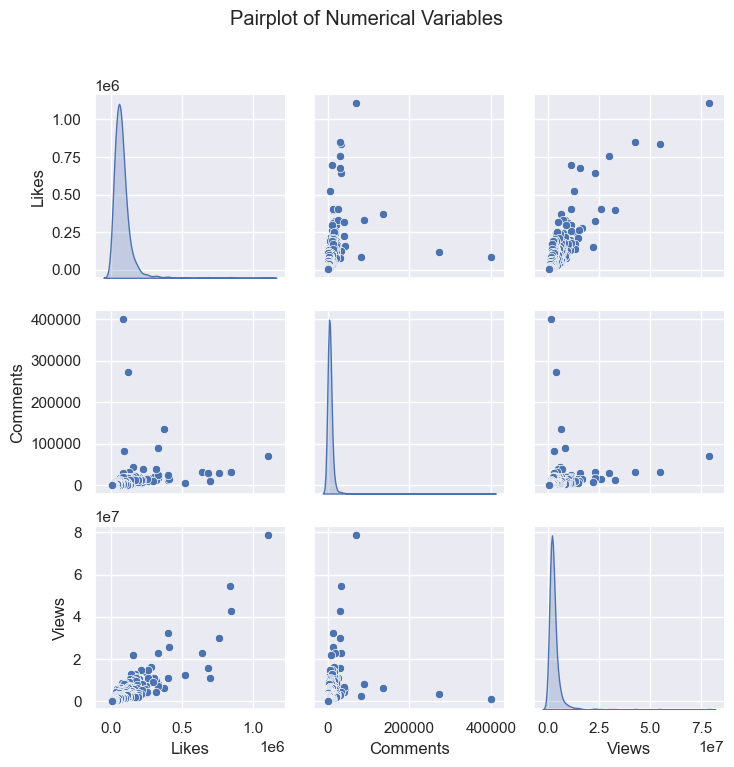

In [83]:
# Pairplot to visualize relationships between numerical variables
sns.pairplot(df[['Likes', 'Comments', 'Views']], diag_kind='kde')
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.tight_layout()

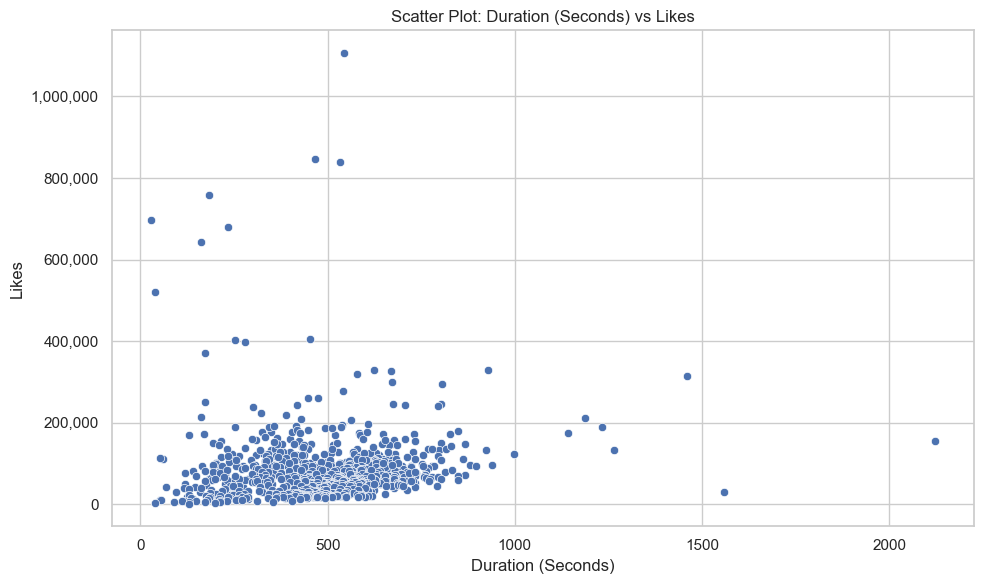

In [84]:
import matplotlib.ticker as ticker
sns.set(style="whitegrid")

# Create a scatter plot of Duration (Seconds) vs Likes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Duration (Seconds)', y='Likes').yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.title('Scatter Plot: Duration (Seconds) vs Likes')
plt.xlabel('Duration (Seconds)')
plt.ylabel('Likes')

plt.tight_layout()
plt.show()

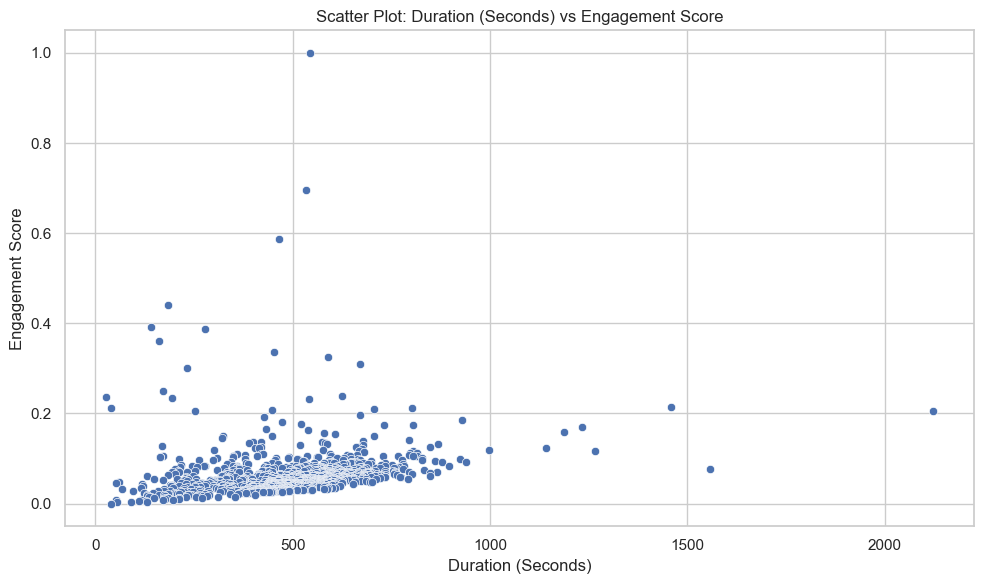

In [85]:
sns.set(style="whitegrid")

# Create a scatter plot of Duration (Seconds) vs Likes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Duration (Seconds)', y='Engagement Score')
plt.title('Scatter Plot: Duration (Seconds) vs Engagement Score')
plt.xlabel('Duration (Seconds)')
plt.ylabel('Engagement Score')

plt.tight_layout()
plt.show()

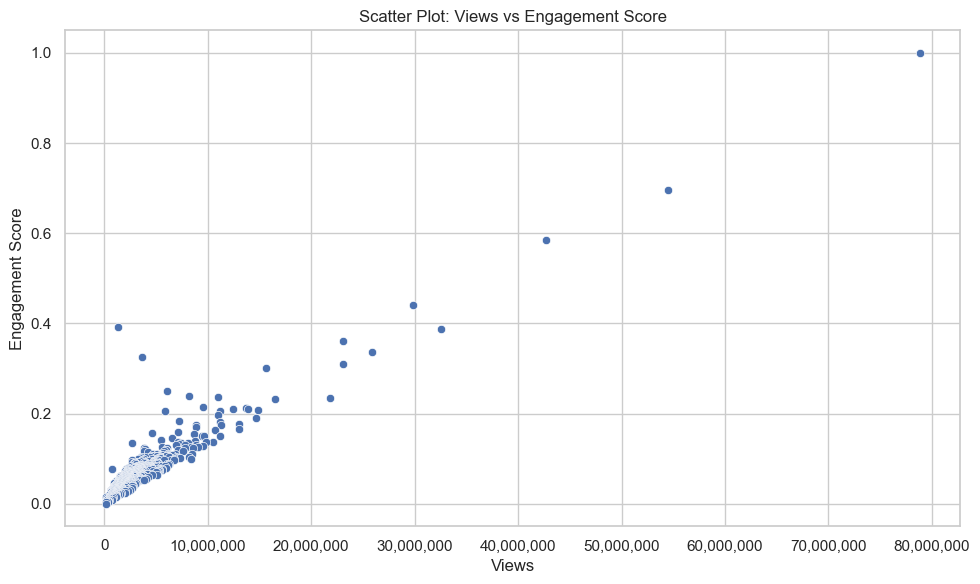

In [86]:
sns.set(style="whitegrid")

# Create a scatter plot of Duration (Seconds) vs Likes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Views', y='Engagement Score').xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.title('Scatter Plot: Views vs Engagement Score')
plt.xlabel('Views')
plt.ylabel('Engagement Score')

plt.tight_layout()
plt.show()

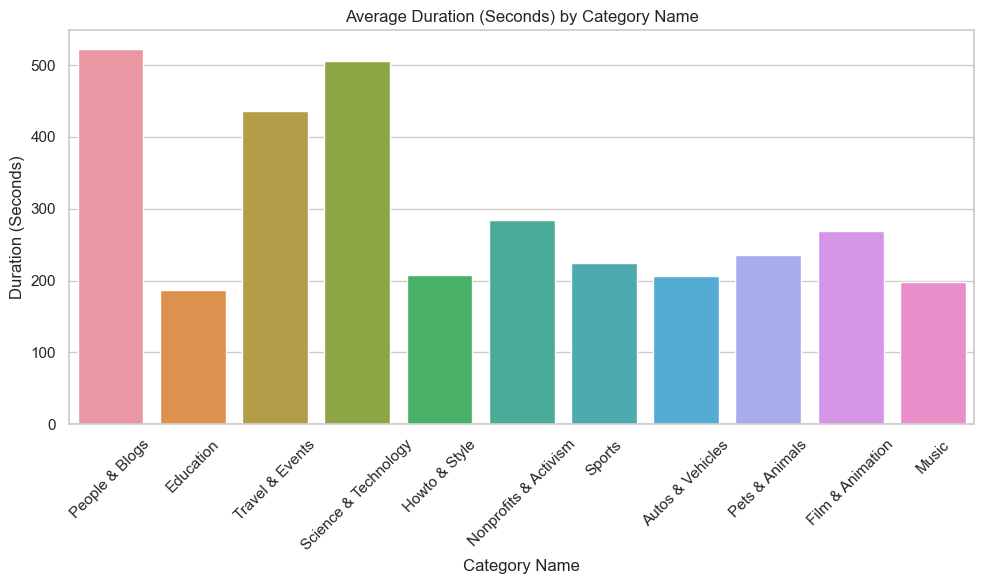

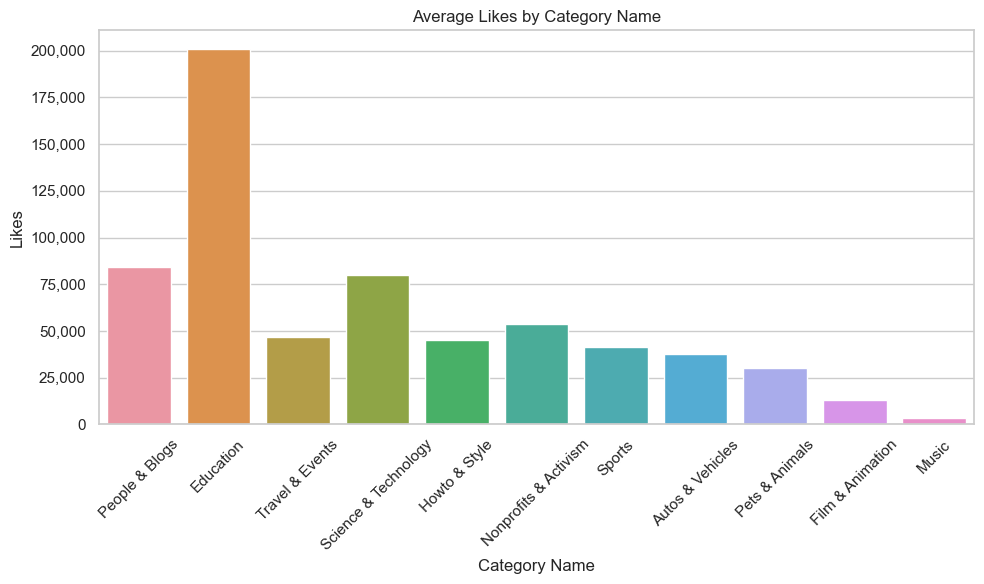

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a bar plot of average Duration (Seconds) by Category Name
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=df, x='Category Name', y='Duration (Seconds)', ci=None)  # Disable confidence intervals
ax1.set_title('Average Duration (Seconds) by Category Name')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)  # Rotate x-axis labels for better readability

# Format y-axis tick labels to display full numbers
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

plt.tight_layout()
plt.show()

# Create a bar plot of average Likes by Category Name
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(data=df, x='Category Name', y='Likes', ci=None)  # Disable confidence intervals
ax2.set_title('Average Likes by Category Name')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)  # Rotate x-axis labels for better readability

# Format y-axis tick labels to display full numbers
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

plt.tight_layout()
plt.show()


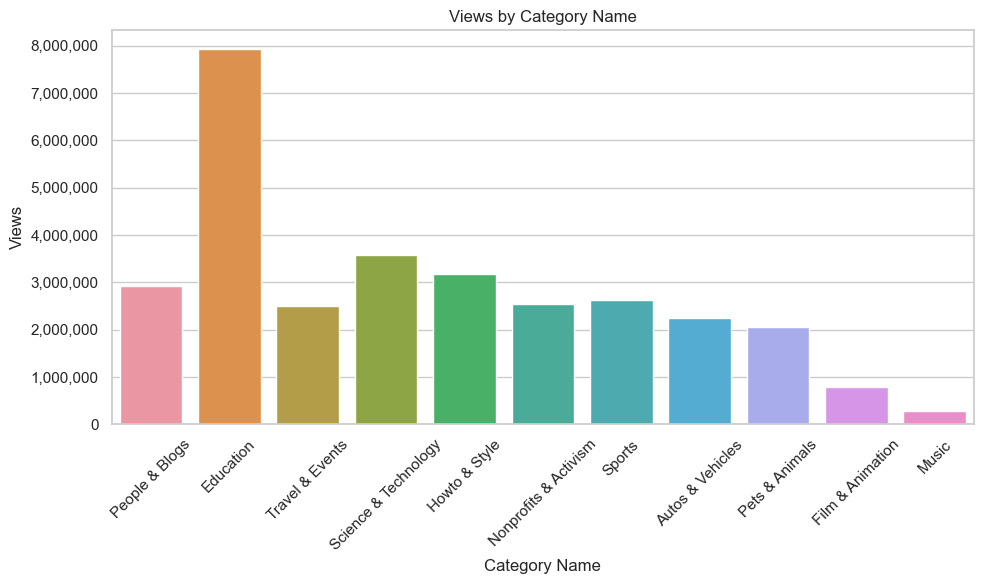

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set the style of seaborn
sns.set(style="whitegrid")


plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=df, x='Category Name', y='Views', ci=None)  # Disable confidence intervals
ax1.set_title('Views by Category Name')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)  # Rotate x-axis labels for better readability

# Format y-axis tick labels to display full numbers
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))

plt.tight_layout()
plt.show()





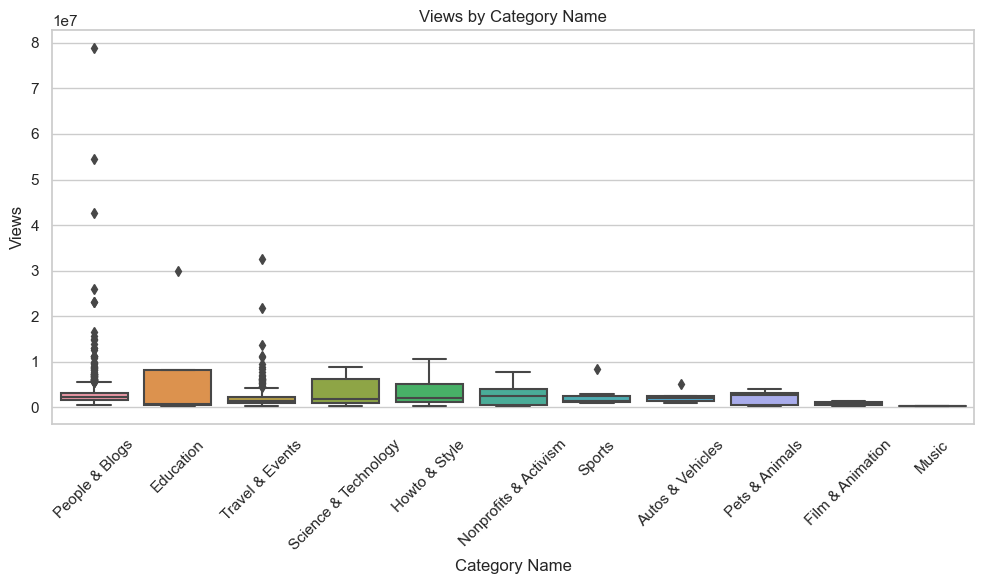

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style of seaborn
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x='Category Name', y='Views')
ax.set_title('Views by Category Name')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)  # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()


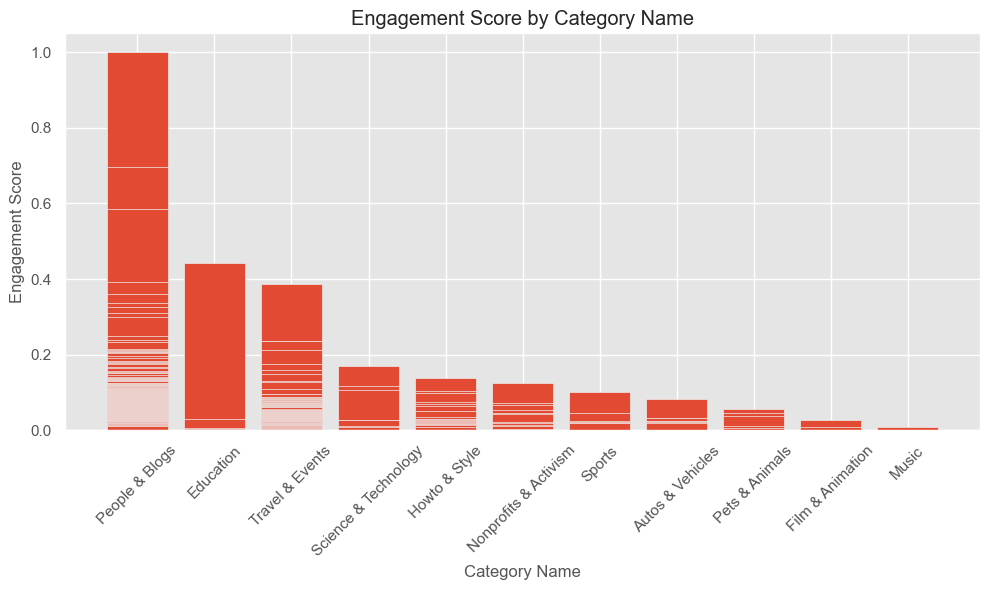

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your DataFrame
# df = ...

# Set the style of matplotlib
plt.style.use('ggplot')

# Create a bar plot of Category Name vs Engagement Score
plt.figure(figsize=(10, 6))
plt.bar(df['Category Name'], df['Engagement Score'])
plt.title('Engagement Score by Category Name')
plt.xlabel('Category Name')
plt.ylabel('Engagement Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



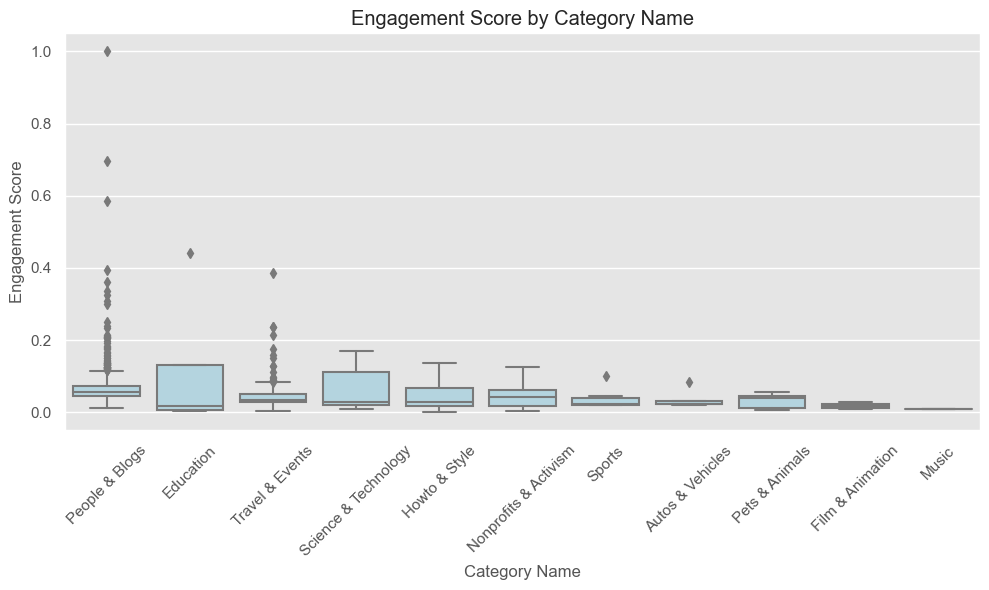

In [59]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of matplotlib
plt.style.use('ggplot')

# Create a figure and axis
plt.figure(figsize=(10, 6))

# Create the box plot
sns.boxplot(x='Category Name', y='Engagement Score', data=df, color='lightblue')

# Set the title and labels
plt.title('Engagement Score by Category Name')
plt.xlabel('Category Name')
plt.ylabel('Engagement Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()




C:\Users\aravi\AppData\Local\Temp\ipykernel_29000\3789915588.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df['Time of the Day'], rotation=45)


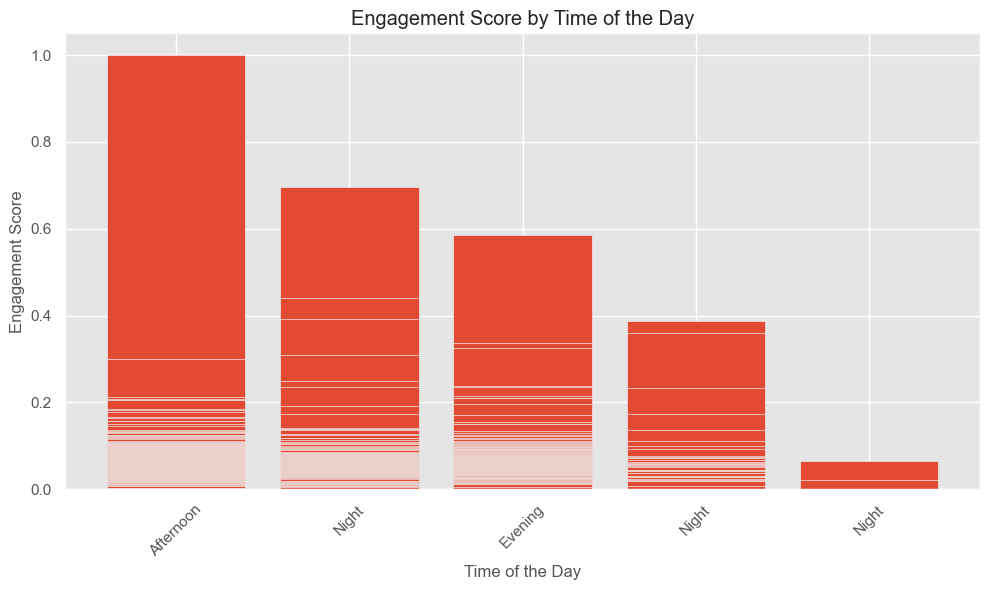

In [90]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create the bar plot
ax.bar(df['Time of the Day'], df['Engagement Score'])

# Set the title and labels
ax.set_title('Engagement Score by Time of the Day')
ax.set_xlabel('Time of the Day')
ax.set_ylabel('Engagement Score')

# Rotate x-axis labels for better readability
ax.set_xticklabels(df['Time of the Day'], rotation=45)

# Format y-axis tick labels to display full numbers
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # Display values as two decimal places

# Display the plot
plt.tight_layout()
plt.show()




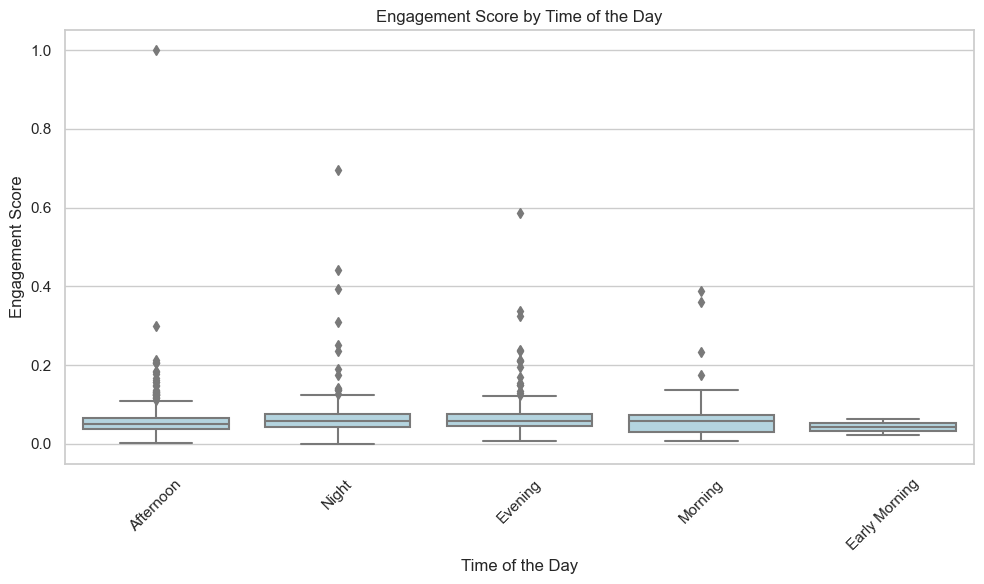

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create the box plot
sns.boxplot(x='Time of the Day', y='Engagement Score', data=df, ax=ax, color='lightblue')

# Set the title and labels
ax.set_title('Engagement Score by Time of the Day')
ax.set_xlabel('Time of the Day')
ax.set_ylabel('Engagement Score')

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# Display the plot
plt.tight_layout()
plt.show()




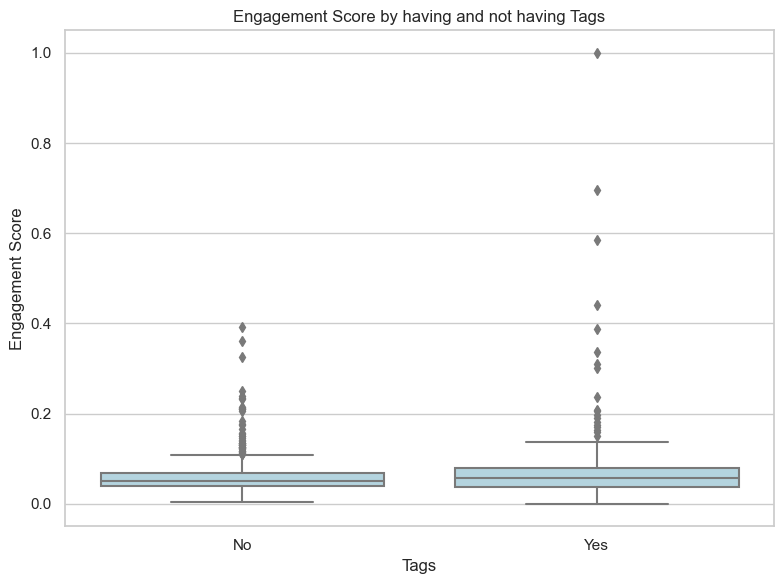

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and axis
plt.figure(figsize=(8, 6))

# Create the box plot
sns.boxplot(x='Tag (Yes=1, No=0)', y='Engagement Score', data=df, color='lightblue')

# Set the title and labels
plt.title('Engagement Score by having and not having Tags')
plt.xlabel('Tags')
plt.ylabel('Engagement Score')

# Set the x-axis tick labels
plt.xticks([0, 1], ['No', 'Yes'])

# Display the plot
plt.tight_layout()
plt.show()




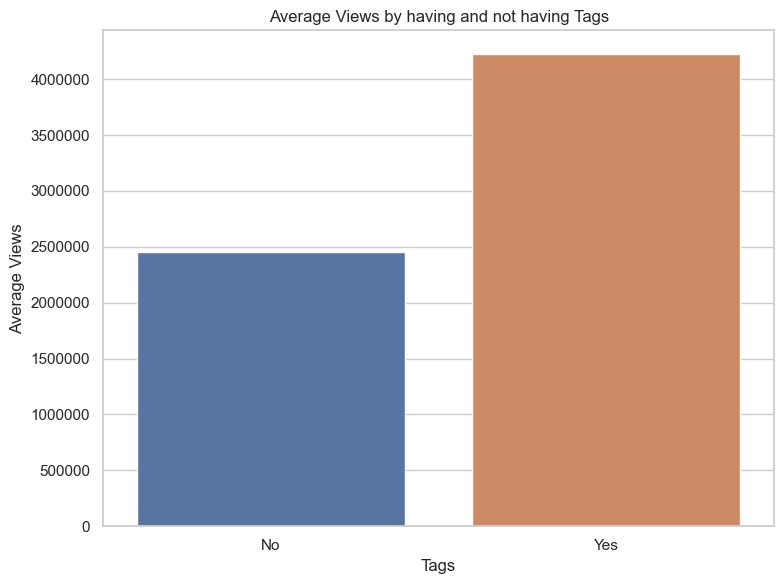

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the average Views for each group
average_views_by_tag = df.groupby('Tag (Yes=1, No=0)')['Views'].mean().reset_index()

# Set the style of Seaborn
sns.set(style="whitegrid")

# Create a figure and axis
plt.figure(figsize=(8, 6))

# Create the bar plot with average Views (default color)
ax = sns.barplot(x='Tag (Yes=1, No=0)', y='Views', data=average_views_by_tag)

# Set the title and labels
ax.set_title('Average Views by having and not having Tags')
ax.set_xlabel('Tags')
ax.set_ylabel('Average Views')
# Set the x-axis tick labels
plt.xticks([0, 1], ['No', 'Yes'])

# Set the y-axis tick labels to display exact numbers
ax.yaxis.set_major_formatter('{:.0f}'.format)

# Display the plot
plt.tight_layout()
plt.show()



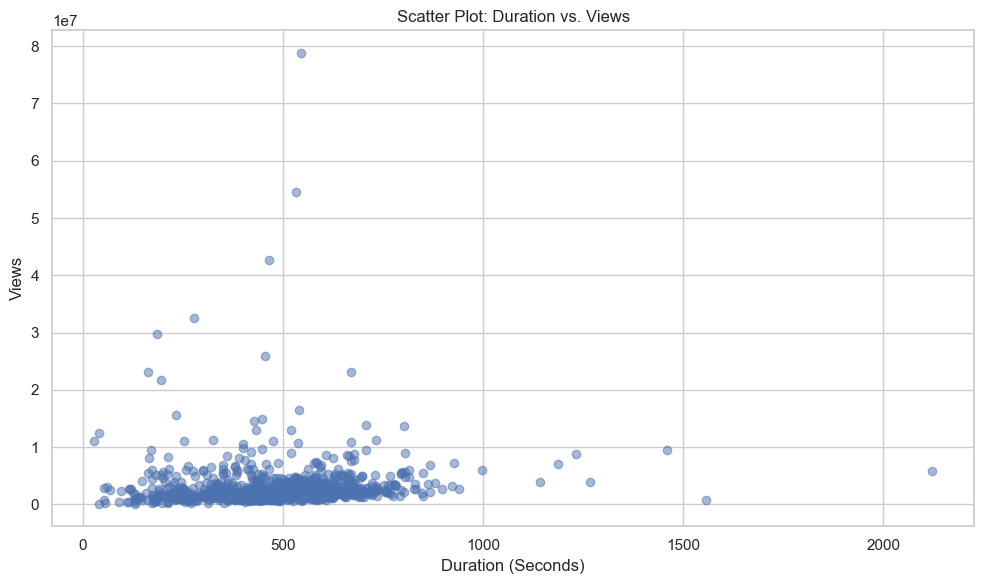

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Create a scatter plot
plt.scatter(df['Duration (Seconds)'], df['Views'], alpha=0.5)

# Adding labels and title
plt.title('Scatter Plot: Duration vs. Views')
plt.xlabel('Duration (Seconds)')
plt.ylabel('Views')

# Display the plot
plt.grid(True)
plt.tight_layout()
plt.show()




## Outlier treatment



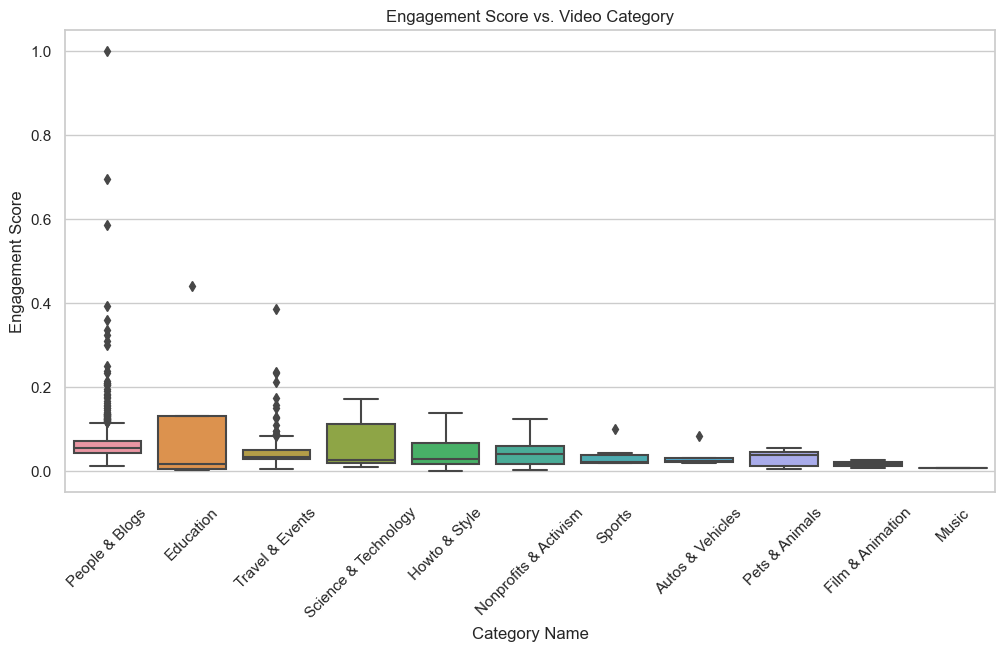

In [73]:

# Boxplot for Engagement Metrics and Engagement Score vs. Category
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category Name', y='Engagement Score', data=df)
plt.xticks(rotation=45)
plt.title('Engagement Score vs. Video Category')
plt.show()

In [74]:

def outlier_treat(data, numerical, factor):
 
 for col in numerical:
        
        
 
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
 
        iqr = Q3 - Q1
 
        upper_whisk = Q3 + (factor*iqr)
        lower_whisk = Q1 - (factor*iqr)
 
        data[col] = np.where(data[col]>upper_whisk, upper_whisk,
        np.where(data[col]<lower_whisk, lower_whisk, data[col]))


In [75]:

numerical_column_1=df.select_dtypes(include=['int', 'float']).columns.tolist()
numerical_column_1


['Views',
 'Likes',
 'Comments',
 'Duration (Seconds)',
 'Tag (Yes=1, No=0)',
 'Engagement Score']

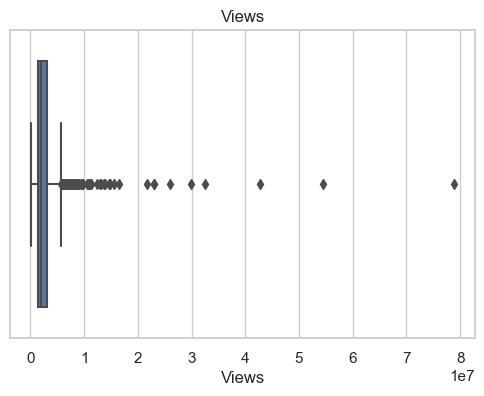

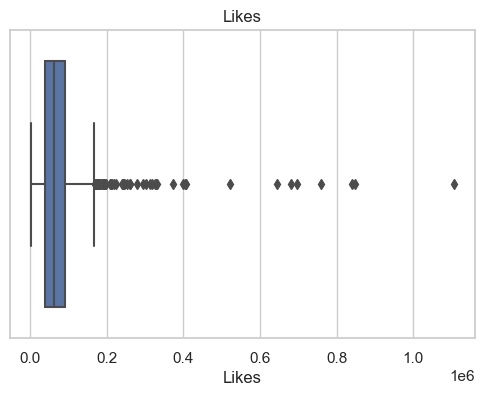

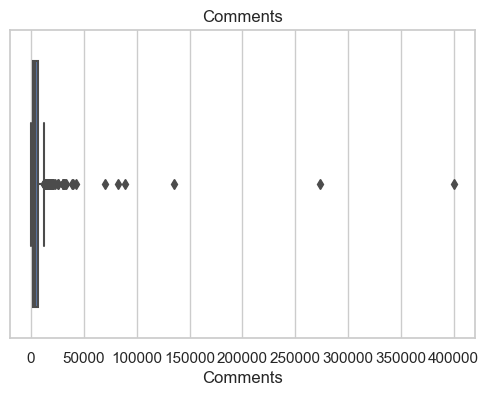

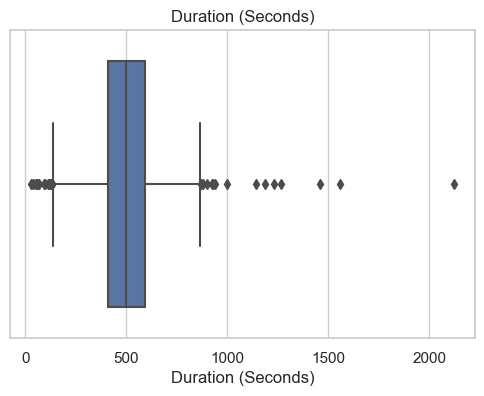

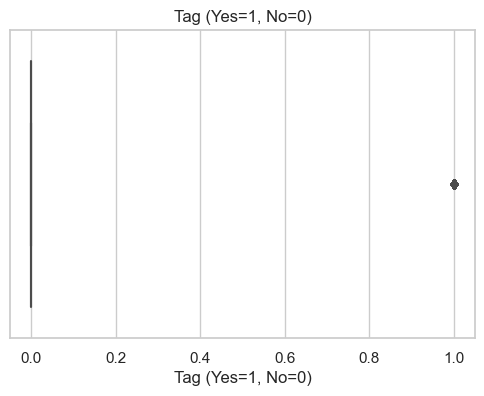

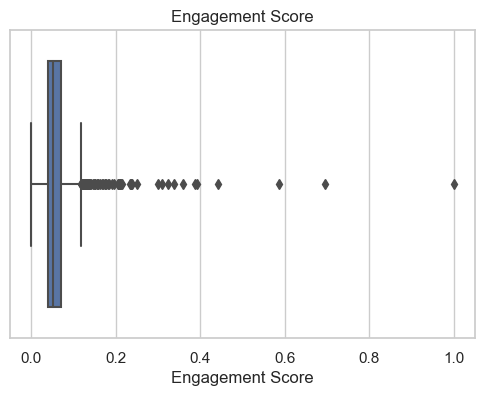

In [76]:

for col in numerical_column_1:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [77]:

numerical_column=['Likes',
'Views',
'Comments','Duration (Seconds)',
'Engagement Score'
]


In [78]:

outlier_treat(df,numerical_column, 1.5)


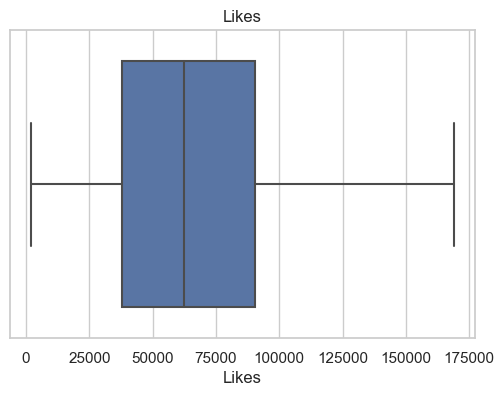

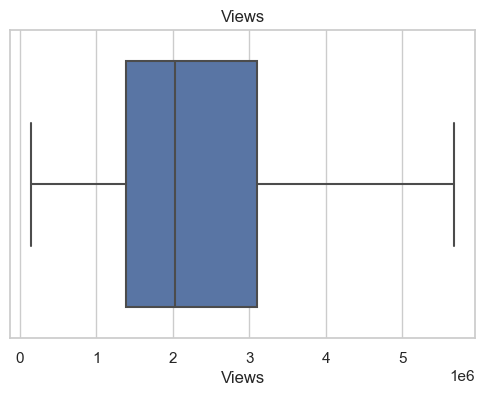

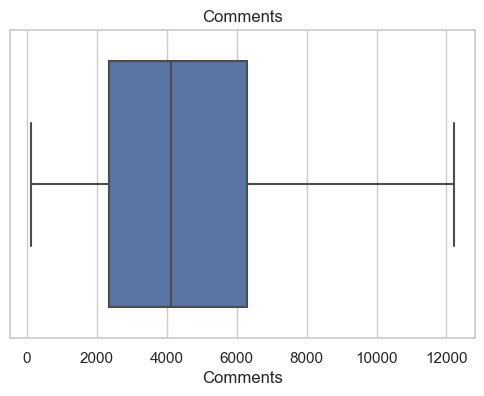

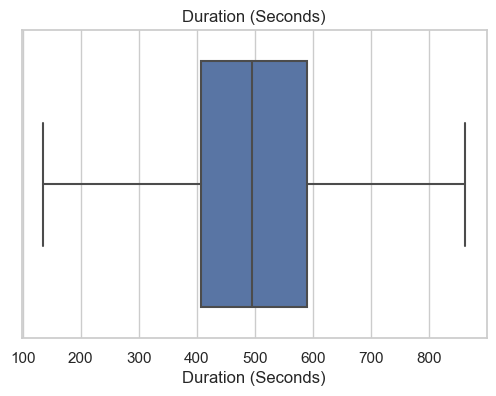

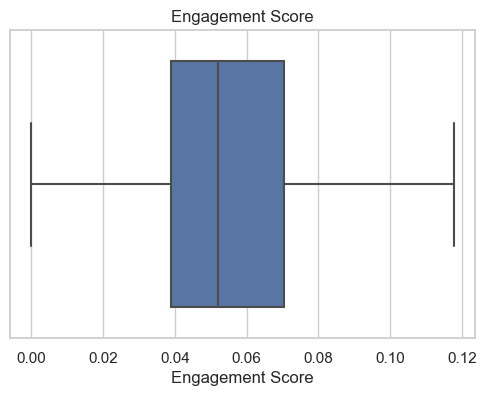

In [79]:

for col in numerical_column:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()



## Scaling

In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df[['Tag (Yes=1, No=0)', 'Category Name', 'Time of the Day', 'Likes', 'Views', 'Comments', 'Duration (Seconds)']]
y = df['Engagement Score']

# One-hot encode categorical variables (e.g., 'Category Name', 'Time of the Day')
X_encoded = pd.get_dummies(X, columns=['Category Name', 'Time of the Day'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Baseline

In [102]:
# Calculate the mean engagement score
from sklearn.metrics import mean_squared_error
mean_engagement = y.mean()

# Create a list of mean engagement scores for the same length as y
baseline_predictions = [mean_engagement] * len(y)

# Calculate the Mean Squared Error for the baseline
baseline_mse = mean_squared_error(y, baseline_predictions)

print(f"Baseline Mean Squared Error: {baseline_mse}")

Baseline Mean Squared Error: 0.0006692720122046381


In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate the mean engagement score
mean_engagement = y.mean()

# Create a list of mean engagement scores for the same length as y
baseline_predictions = [mean_engagement] * len(y)

# Calculate the Mean Squared Error (MSE) for the baseline
baseline_mse = mean_squared_error(y, baseline_predictions)

# Calculate the Root Mean Squared Error (RMSE)
baseline_rmse = np.sqrt(baseline_mse)

# Calculate the Mean Absolute Error (MAE)
baseline_mae = mean_absolute_error(y, baseline_predictions)



print(f"Baseline MSE: {baseline_mse}")
print(f"Baseline RMSE: {baseline_rmse}")
print(f"Baseline MAE: {baseline_mae}")



Baseline MSE: 0.0006692720122046381
Baseline RMSE: 0.02587029207806974
Baseline MAE: 0.020378709045700126


## Multiple Linear Regression

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
import numpy as np

# Assuming you have loaded and preprocessed your data into X_train_scaled, X_test_scaled, y_train, and y_test

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the original features
model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Calculate Mean Squared Error (MSE) to evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")

# Assuming you have trained your Linear Regression model and obtained predictions
y_train_pred = model.predict(X_train_scaled)

# Calculate Mean Squared Error (MSE) for training data
mse_train = mean_squared_error(y_train, y_train_pred)

# Calculate RMSE for training data
rmse_train = np.sqrt(mse_train)

# Calculate MAE for training data
mae_train = mean_absolute_error(y_train, y_train_pred)

print("Mean Squared Error (Train):", mse_train)
print("Root Mean Squared Error (Train):", rmse_train)
print("Mean Absolute Error (Train):", mae_train)


Mean Squared Error: 1.26215204833285e-05
Root Mean Squared Error: 0.0035526779312693825
Mean Absolute Error: 0.0020724164453829012
Mean Squared Error (Train): 1.9344721384726094e-05
Root Mean Squared Error (Train): 0.004398263451036794
Mean Absolute Error (Train): 0.0019710807287557108


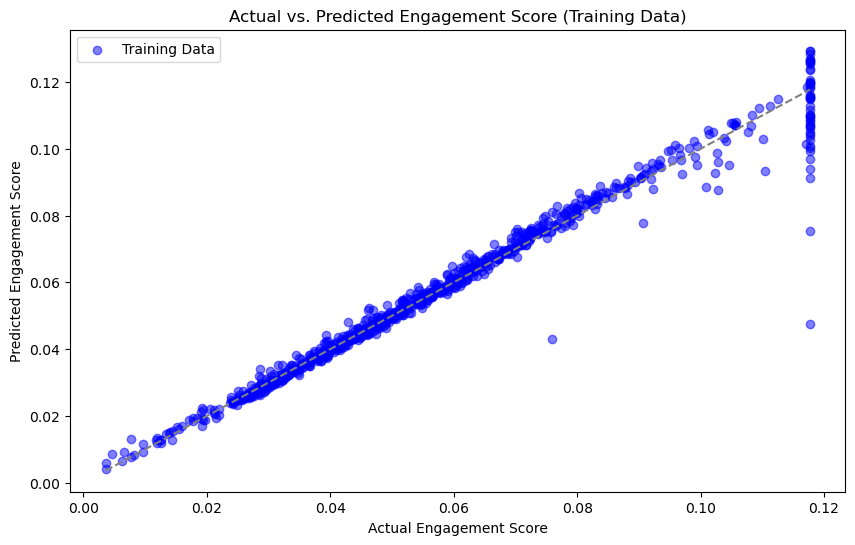

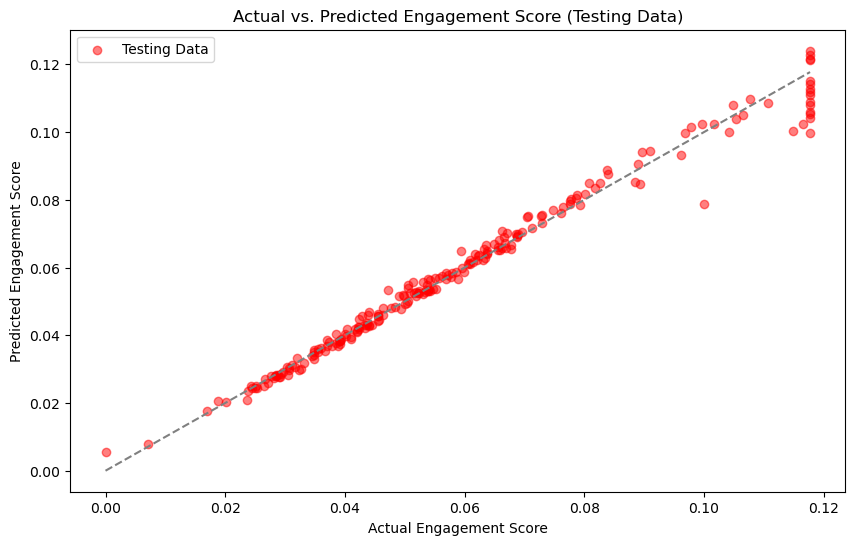

In [16]:
import matplotlib.pyplot as plt

# Visualize the results using scatter plots
plt.figure(figsize=(10, 6))

# Plot the actual vs. predicted values for training data
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.5, label='Training Data')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='gray', linestyle='--')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.title('Actual vs. Predicted Engagement Score (Training Data)')
plt.legend()

# Plot the actual vs. predicted values for testing data
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='red', alpha=0.5, label='Testing Data')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='gray', linestyle='--')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.title('Actual vs. Predicted Engagement Score (Testing Data)')
plt.legend()

plt.show()


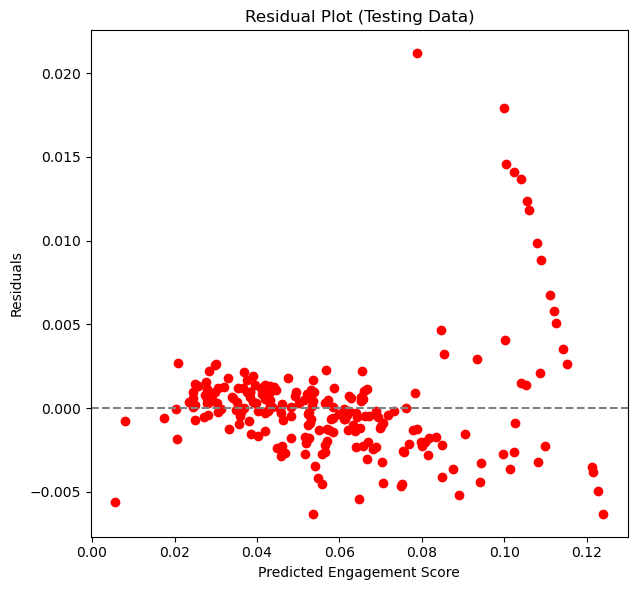

In [17]:
import matplotlib.pyplot as plt

# Calculate the residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_pred

# Create residual plots
plt.figure(figsize=(12, 6))


# Residual plot for testing data
plt.subplot(1, 2, 2)
plt.scatter(y_pred, test_residuals, color='red')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Predicted Engagement Score')
plt.ylabel('Residuals')
plt.title('Residual Plot (Testing Data)')

plt.tight_layout()
plt.show()


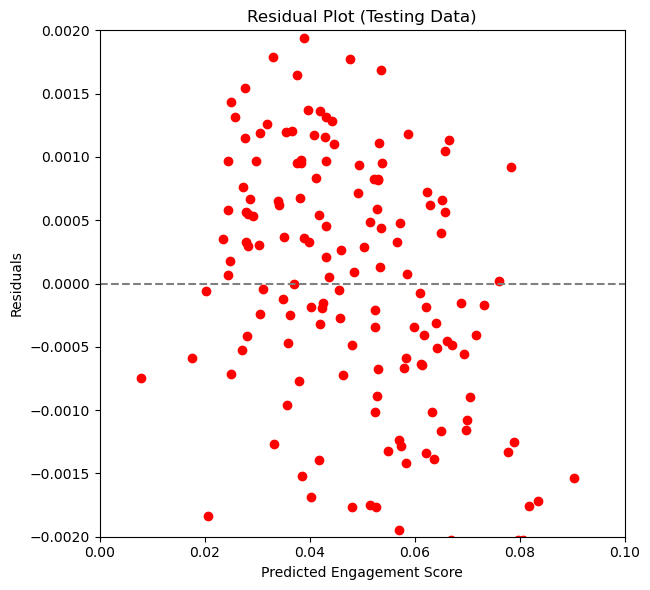

In [37]:
import matplotlib.pyplot as plt

# Calculate the residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_pred

# Create residual plots
plt.figure(figsize=(12, 6))



# Residual plot for testing data
plt.subplot(1, 2, 2)
plt.scatter(y_pred, test_residuals, color='red')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Predicted Engagement Score')
plt.ylabel('Residuals')
plt.title('Residual Plot (Testing Data)')

# Set limits for the y-axis
plt.ylim(-0.002, 0.0020)  # Adjust the limits as needed
plt.xlim(0.0, 0.10)
plt.tight_layout()
plt.show()


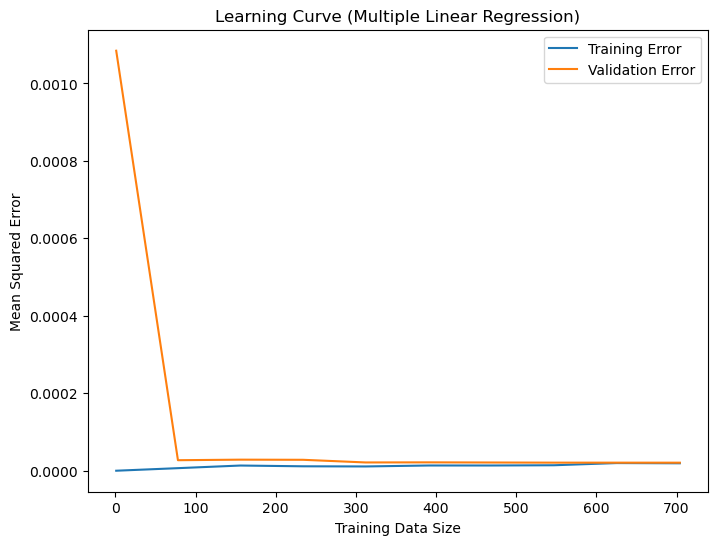

In [18]:
from sklearn.model_selection import learning_curve

# Create learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.000001, 1, 10)
)

# Calculate mean squared errors
train_errors = -train_scores.mean(axis=1)
test_errors = -test_scores.mean(axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_errors, label='Training Error')
plt.plot(train_sizes, test_errors, label='Validation Error')
plt.xlabel('Training Data Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve (Multiple Linear Regression)')
plt.legend()
plt.show()


## Decision Tree Regression

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error


In [16]:
# Create the DecisionTreeRegressor model
model = DecisionTreeRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [17]:
# Make predictions on both training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [18]:
# Calculate the Mean Squared Errors
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"Mean Squared Error (Training): {mse_train}")
print(f"Mean Squared Error (Testing): {mse_test}")

Mean Squared Error (Training): 3.0639794569796934e-35
Mean Squared Error (Testing): 2.9435282649827546e-05


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate MSE for training and testing sets
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# Calculate RMSE for training and testing sets
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

# Calculate MAE for training and testing sets
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Mean Squared Error (Training): {mse_train}")
print(f"Mean Squared Error (Testing): {mse_test}")
print(f"Root Mean Squared Error (Training): {rmse_train}")
print(f"Root Mean Squared Error (Testing): {rmse_test}")
print(f"Mean Absolute Error (Training): {mae_train}")
print(f"Mean Absolute Error (Testing): {mae_test}")


Mean Squared Error (Training): 3.0639794569796934e-35
Mean Squared Error (Testing): 2.9435282649827546e-05
Root Mean Squared Error (Training): 5.535322444970747e-18
Root Mean Squared Error (Testing): 0.005425429259498971
Mean Absolute Error (Training): 1.1039149392579681e-18
Mean Absolute Error (Testing): 0.003461923447383735


Text(0, 0.5, 'Predicted Engagement Score')

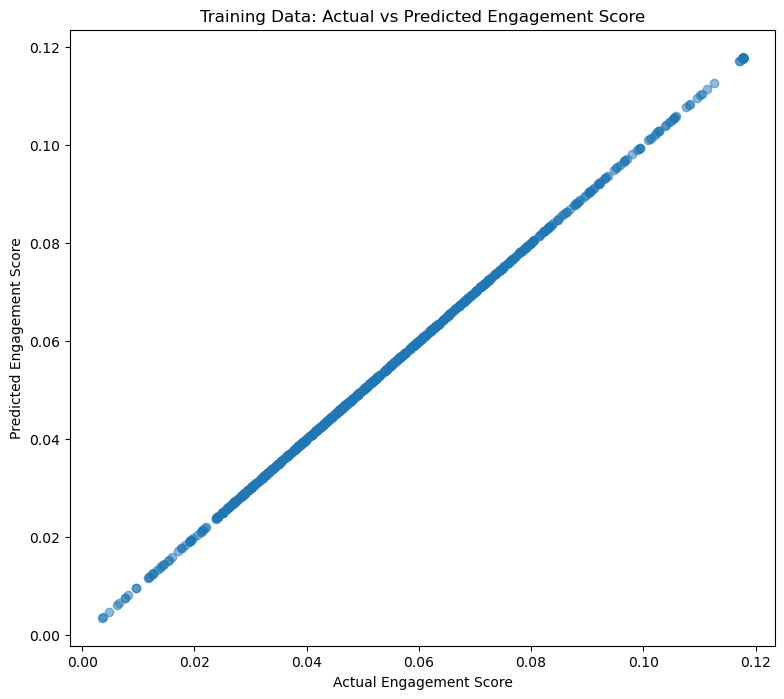

In [20]:
# Plot scatter plots for model performance
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.title('Training Data: Actual vs Predicted Engagement Score')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')

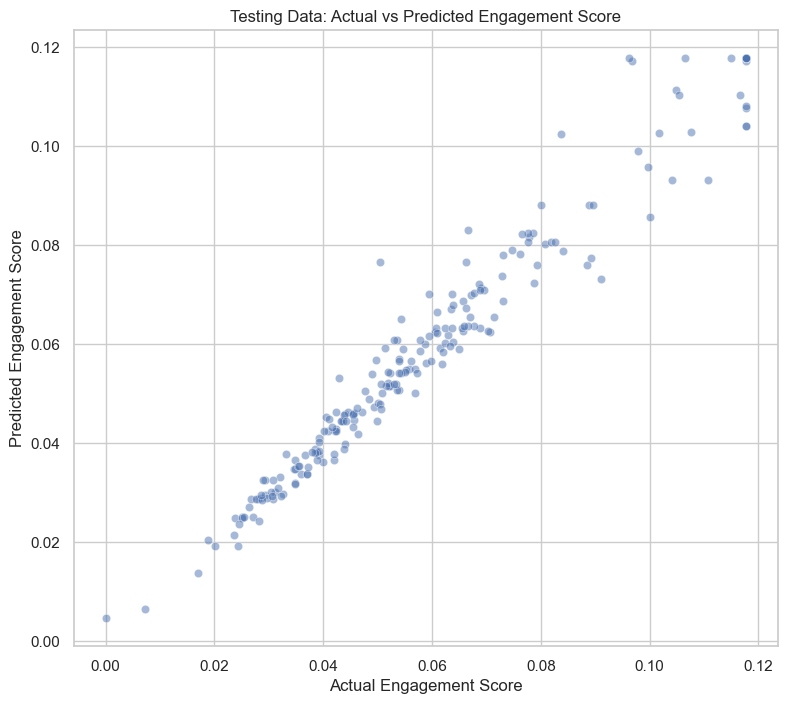

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming you have y_test and y_test_pred defined

# Set Seaborn style
sns.set(style="whitegrid")

# Create a scatter plot
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5)
plt.title('Testing Data: Actual vs Predicted Engagement Score')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')

# Show the plot
plt.show()


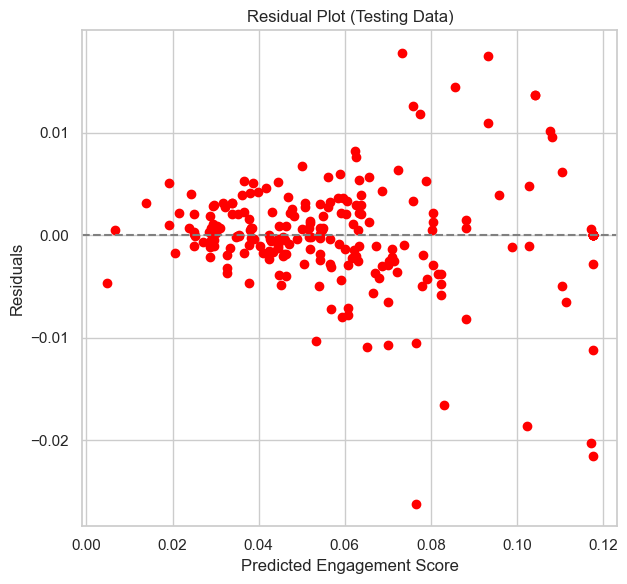

In [23]:
# Calculate the residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

# Create residual plots
plt.figure(figsize=(12, 6))


# Residual plot for testing data
plt.subplot(1, 2, 2)
plt.scatter(y_test_pred, test_residuals, color='red')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Predicted Engagement Score')
plt.ylabel('Residuals')
plt.title('Residual Plot (Testing Data)')



plt.tight_layout()
plt.show()

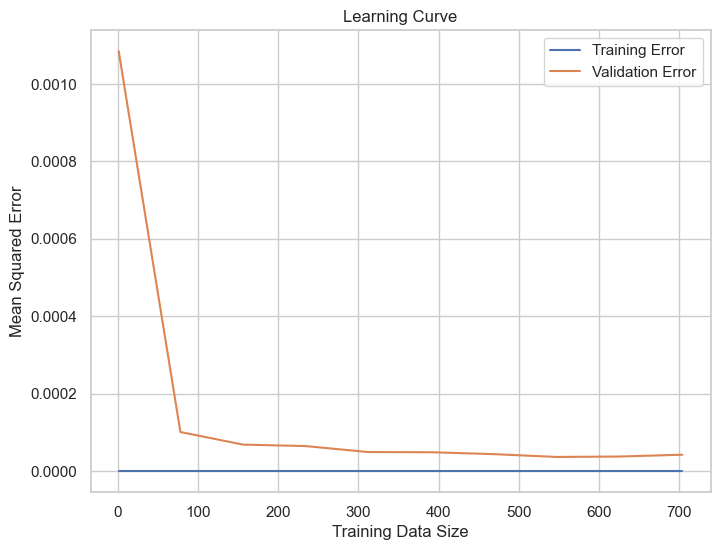

In [24]:
from sklearn.model_selection import learning_curve

# Create learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.000001, 1, 10)
)

# Calculate mean squared errors
train_errors = -train_scores.mean(axis=1)
test_errors = -test_scores.mean(axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_errors, label='Training Error')
plt.plot(train_sizes, test_errors, label='Validation Error')
plt.xlabel('Training Data Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

## KNN Regression

In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [16]:
# Create KNN Regression model
knn_model = KNeighborsRegressor(n_neighbors=5)  # You can adjust the number of neighbors
knn_model.fit(X_train_scaled, y_train)


KNeighborsRegressor()

In [17]:
# Make predictions for training and testing data
y_train_pred = knn_model.predict(X_train_scaled)
y_test_pred = knn_model.predict(X_test_scaled)

# Calculate MSE for training and testing data
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print("Mean Squared Error (Train):", mse_train)
print("Mean Squared Error (Test):", mse_test)

Mean Squared Error (Train): 4.555465315073462e-05
Mean Squared Error (Test): 0.00015618994188221086


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Make predictions for training and testing data
y_train_pred = knn_model.predict(X_train_scaled)
y_test_pred = knn_model.predict(X_test_scaled)

# Calculate MSE for training and testing data
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# Calculate RMSE for training and testing data
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

# Calculate MAE for training and testing data
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("Mean Squared Error (Train):", mse_train)
print("Mean Squared Error (Test):", mse_test)
print("Root Mean Squared Error (Train):", rmse_train)
print("Root Mean Squared Error (Test):", rmse_test)
print("Mean Absolute Error (Train):", mae_train)
print("Mean Absolute Error (Test):", mae_test)

Mean Squared Error (Train): 4.555465315073462e-05
Mean Squared Error (Test): 0.00015618994188221086
Root Mean Squared Error (Train): 0.006749418726878236
Root Mean Squared Error (Test): 0.012497597444397497
Mean Absolute Error (Train): 0.0036399523172057956
Mean Absolute Error (Test): 0.005292555489943322


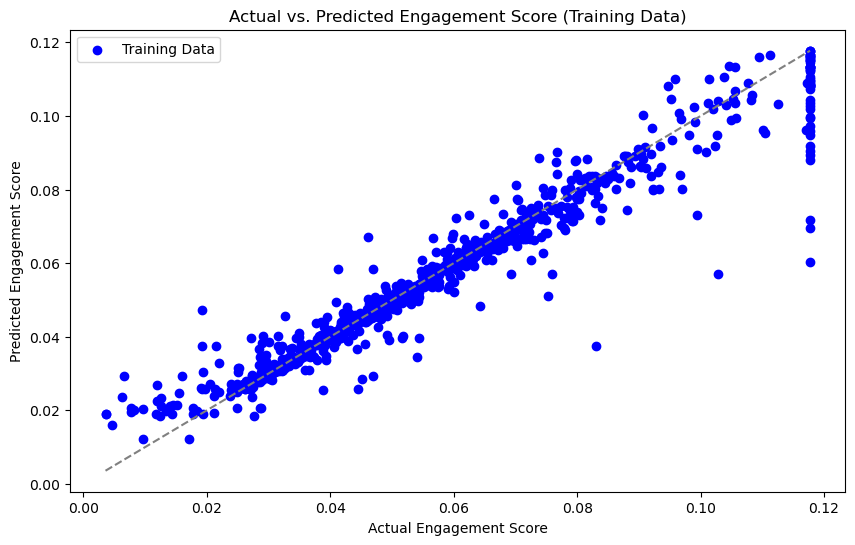

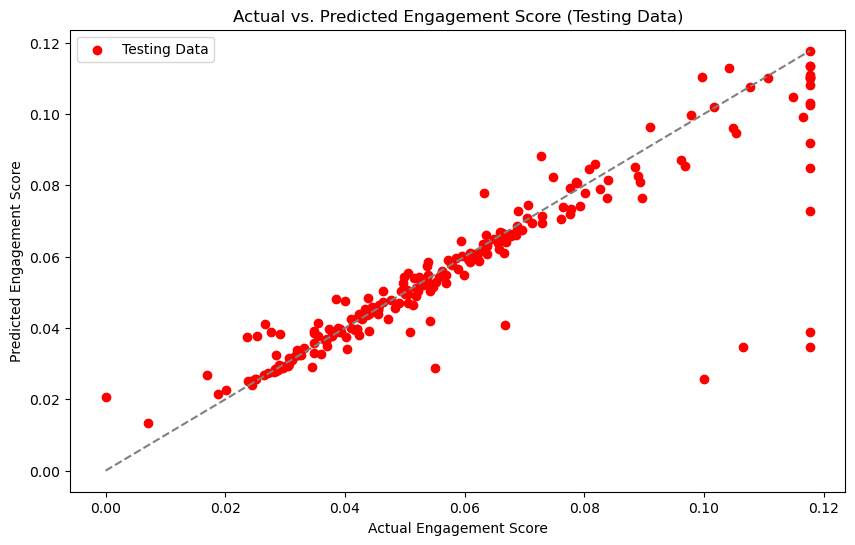

In [19]:
# Visualize the results using scatter plots
plt.figure(figsize=(10, 6))

# Plot the actual vs. predicted values for training data
plt.scatter(y_train, y_train_pred, color='blue', label='Training Data')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='gray', linestyle='--')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.title('Actual vs. Predicted Engagement Score (Training Data)')
plt.legend()
plt.show()

# Plot the actual vs. predicted values for testing data
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='red', label='Testing Data')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='gray', linestyle='--')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.title('Actual vs. Predicted Engagement Score (Testing Data)')
plt.legend()
plt.show()





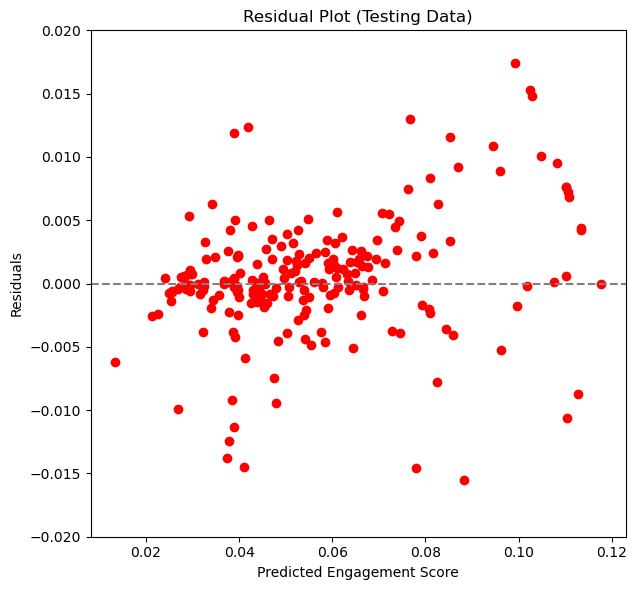

In [23]:
# Calculate the residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

# Create residual plots
plt.figure(figsize=(12, 6))



# Residual plot for testing data
plt.subplot(1, 2, 2)
plt.scatter(y_test_pred, test_residuals, color='red')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Predicted Engagement Score')
plt.ylabel('Residuals')
plt.title('Residual Plot (Testing Data)')

# Set limits for the y-axis
plt.ylim(-0.02, 0.020)  # Adjust the limits as needed

plt.tight_layout()
plt.show()

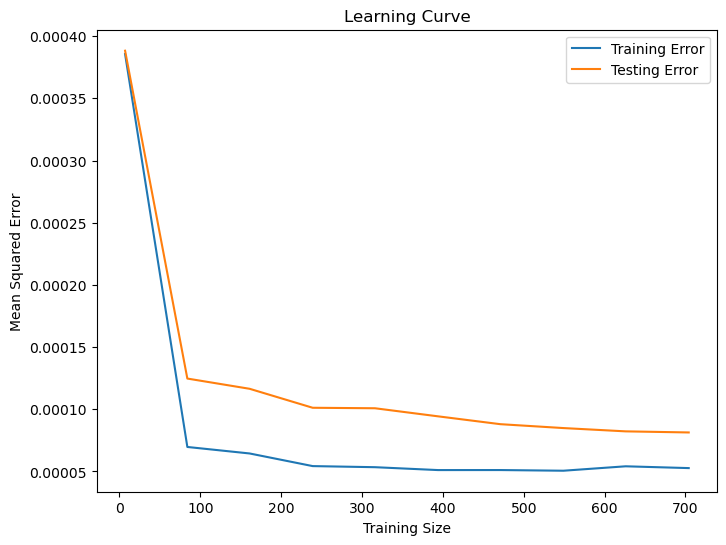

In [21]:
from sklearn.model_selection import learning_curve
# Create learning curve
train_sizes, train_scores, test_scores = learning_curve(
    knn_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.01, 1.0, 10)
)

train_errors = -train_scores.mean(axis=1)
test_errors = -test_scores.mean(axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_errors, label='Training Error')
plt.plot(train_sizes, test_errors, label='Testing Error')
plt.xlabel('Training Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

## Random Forest Regression

In [17]:
from sklearn.ensemble import RandomForestRegressor

In [18]:
# Create and train the RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(max_depth=6, random_state=42)

In [19]:
# Make predictions on both training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [20]:
# Calculate the Mean Squared Error (MSE) for training and testing data
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"Mean Squared Error (Train): {mse_train:.8f}")
print(f"Mean Squared Error (Test): {mse_test:.8f}")

Mean Squared Error (Train): 0.00000860
Mean Squared Error (Test): 0.00002001


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate MSE for training and testing data
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# Calculate RMSE for training and testing data
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

# Calculate MAE for training and testing data
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Mean Squared Error (Train): {mse_train:.8f}")
print(f"Mean Squared Error (Test): {mse_test:.8f}")
print(f"Root Mean Squared Error (Train): {rmse_train:.8f}")
print(f"Root Mean Squared Error (Test): {rmse_test:.8f}")
print(f"Mean Absolute Error (Train): {mae_train:.8f}")
print(f"Mean Absolute Error (Test): {mae_test:.8f}")

Mean Squared Error (Train): 0.00000860
Mean Squared Error (Test): 0.00002001
Root Mean Squared Error (Train): 0.00293228
Root Mean Squared Error (Test): 0.00447333
Mean Absolute Error (Train): 0.00182658
Mean Absolute Error (Test): 0.00284967


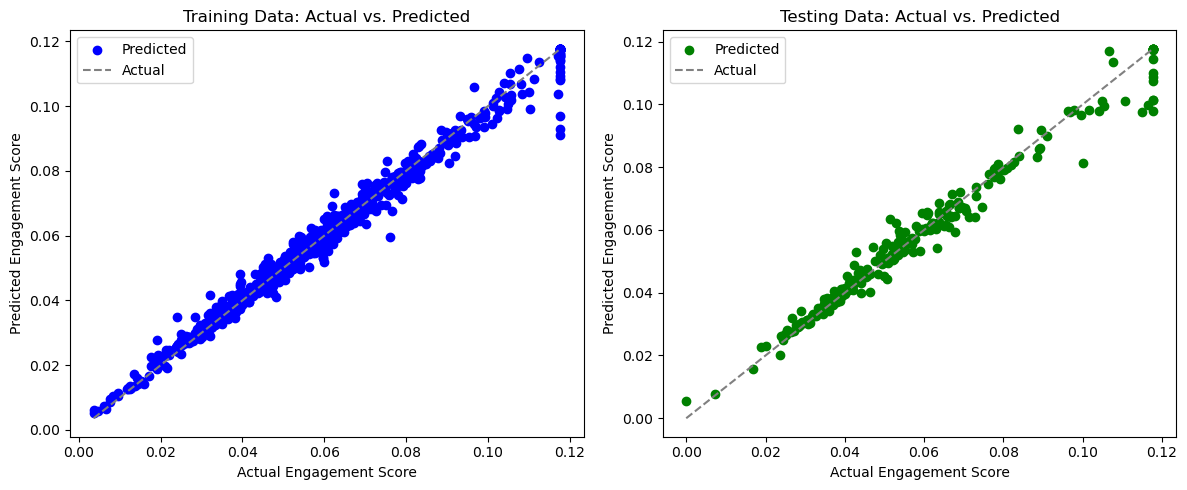

In [22]:
# Create scatter plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, color='blue', label='Predicted')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], linestyle='--', color='gray', label='Actual')
plt.title('Training Data: Actual vs. Predicted')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, color='green', label='Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='gray', label='Actual')
plt.title('Testing Data: Actual vs. Predicted')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.legend()

plt.tight_layout()
plt.show()

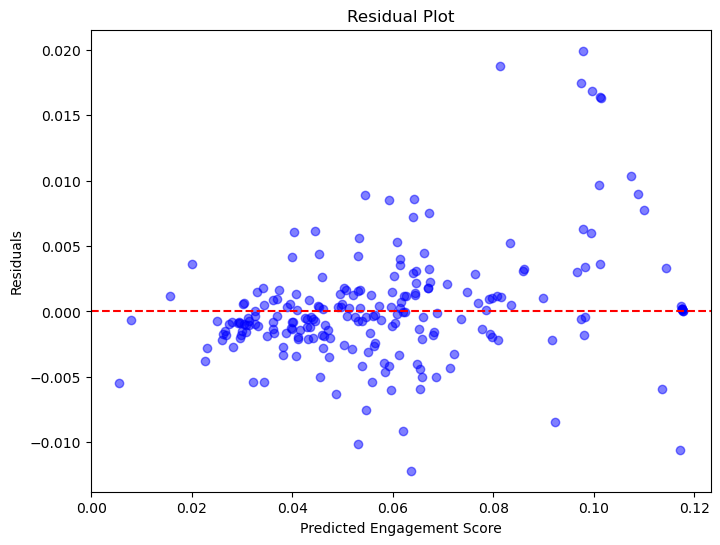

In [23]:
# Calculate the residuals
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, color='blue', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Engagement Score')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

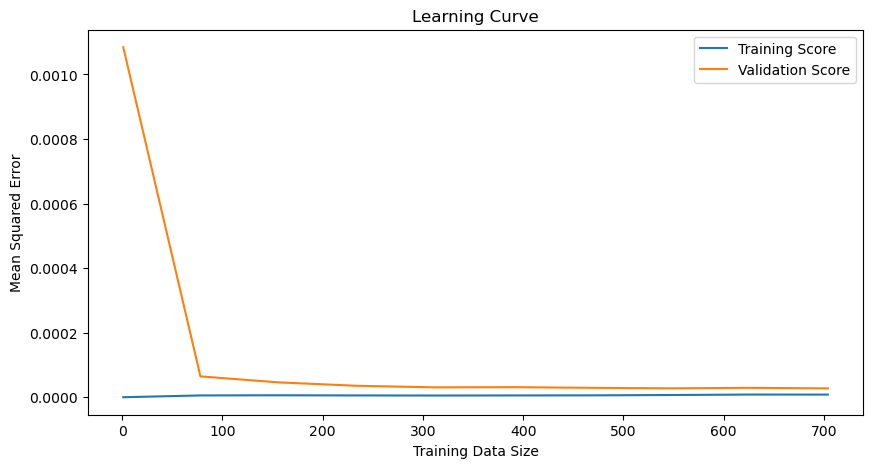

In [24]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Create learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5, train_sizes=np.linspace(0.000001, 1, 10),
    scoring='neg_mean_squared_error'
)

# Calculate mean squared errors
train_errors = -train_scores
test_errors = -test_scores

# Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(train_sizes, np.mean(train_errors, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_errors, axis=1), label='Validation Score')
plt.xlabel('Training Data Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()


## Gradient Boosting Regression

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

In [16]:
gb_regressor = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

In [17]:
# Step 5: Train the model on the training data
gb_regressor.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [18]:
# Step 6: Make predictions on the testing data
y_pred = gb_regressor.predict(X_test)

In [19]:
# Step 7: Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
y_pred_train = gb_regressor.predict(X_train)
print("Mean Squared Error:", mse)

Mean Squared Error: 1.4939608932921407e-05


In [20]:
# Step 6: Make predictions on the testing data
y_pred_test = gb_regressor.predict(X_test)
y_pred_train = gb_regressor.predict(X_train)

In [21]:
# Step 7: Calculate Mean Squared Error (MSE) for testing and training data
mse_test = mean_squared_error(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
print("MSE for Testing Data:", mse_test)
print("MSE for Training Data:", mse_train)

MSE for Testing Data: 1.4939608932921407e-05
MSE for Training Data: 3.172018492536667e-06


In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate MSE for testing and training sets
mse_test = mean_squared_error(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)

# Calculate RMSE for testing and training sets
rmse_test = np.sqrt(mse_test)
rmse_train = np.sqrt(mse_train)

# Calculate MAE for testing and training sets
mae_test = mean_absolute_error(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)

print("Mean Squared Error (MSE) for Testing Data:", mse_test)
print("Mean Squared Error (MSE) for Training Data:", mse_train)
print("Root Mean Squared Error (RMSE) for Testing Data:", rmse_test)
print("Root Mean Squared Error (RMSE) for Training Data:", rmse_train)
print("Mean Absolute Error (MAE) for Testing Data:", mae_test)
print("Mean Absolute Error (MAE) for Training Data:", mae_train)

Mean Squared Error (MSE) for Testing Data: 1.4939608932921407e-05
Mean Squared Error (MSE) for Training Data: 3.172018492536667e-06
Root Mean Squared Error (RMSE) for Testing Data: 0.003865179029866716
Root Mean Squared Error (RMSE) for Training Data: 0.001781016140448106
Mean Absolute Error (MAE) for Testing Data: 0.0021862617948932963
Mean Absolute Error (MAE) for Training Data: 0.0011605056883281454


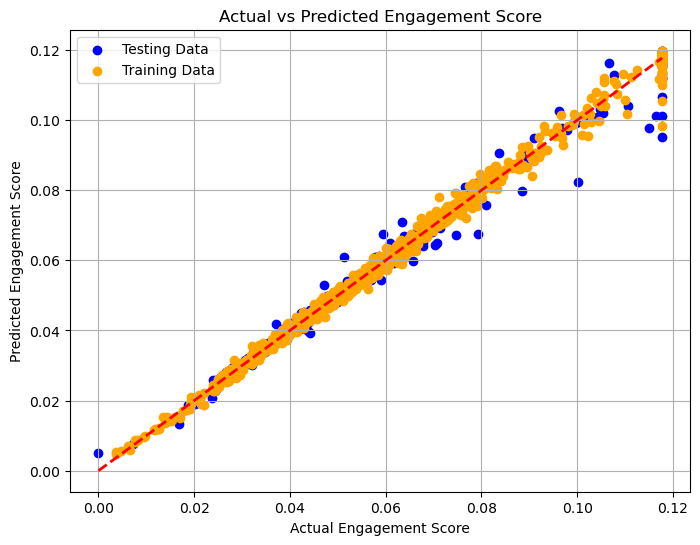

In [23]:
# Step 8: Visualize the results with a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color='blue', label='Testing Data')
plt.scatter(y_train, y_pred_train, color='orange', label='Training Data')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.title('Actual vs Predicted Engagement Score')
plt.legend()
plt.grid(True)
plt.show()

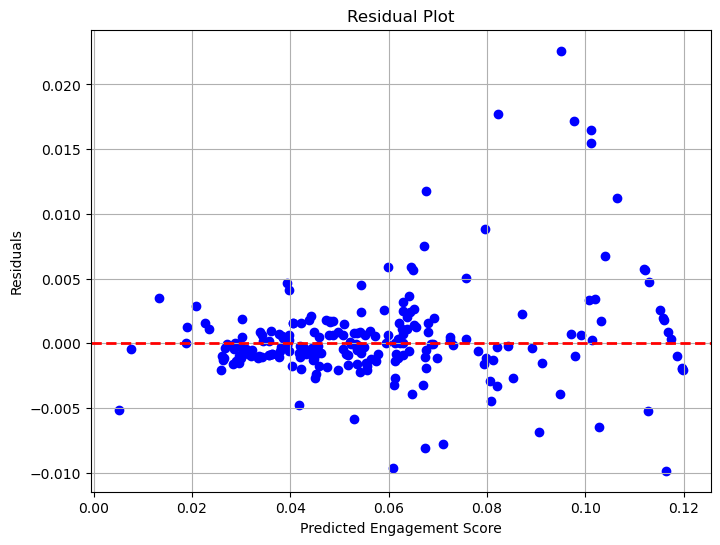

In [25]:
# Calculate residuals
residuals = y_test - y_pred_test

# Create a residual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Engagement Score')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()



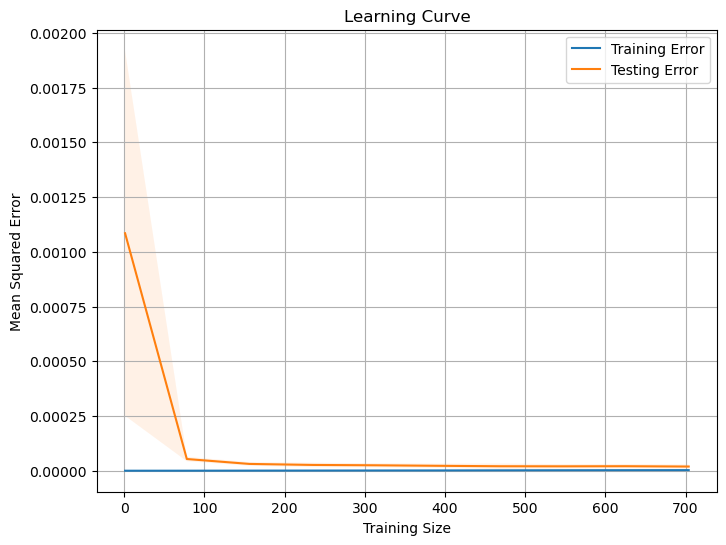

In [25]:
from sklearn.model_selection import learning_curve

# Define the training data sizes you want to use
train_sizes = np.linspace(0.001, 1.0, 10)

# Create learning curve and obtain training and testing scores
train_sizes, train_scores, test_scores = learning_curve(
    gb_regressor, X_train_scaled, y_train, cv=5, train_sizes=train_sizes, scoring='neg_mean_squared_error'
)

# Calculate mean and standard deviation for training and testing scores
train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Step 7: Create a learning curve plot
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Error')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1)
plt.plot(train_sizes, test_scores_mean, label='Testing Error')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1)
plt.xlabel('Training Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


## Neural Network Regression

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

In [17]:
# Initialize the MLPRegressor (Neural Network) model
model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42)

# Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled training and testing data
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate and print the Mean Squared Error for both training and testing data
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'Mean Squared Error (Train): {mse_train:.8f}')
print(f'Mean Squared Error (Test): {mse_test:.8f}')


Mean Squared Error (Train): 0.00097440
Mean Squared Error (Test): 0.00145979


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate MSE for training and testing data
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# Calculate RMSE for training and testing data
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

# Calculate MAE for training and testing data
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f'Mean Squared Error (Train): {mse_train:.8f}')
print(f'Mean Squared Error (Test): {mse_test:.8f}')
print(f'Root Mean Squared Error (Train): {rmse_train:.8f}')
print(f'Root Mean Squared Error (Test): {rmse_test:.8f}')
print(f'Mean Absolute Error (Train): {mae_train:.8f}')
print(f'Mean Absolute Error (Test): {mae_test:.8f}')

Mean Squared Error (Train): 0.00097440
Mean Squared Error (Test): 0.00145979
Root Mean Squared Error (Train): 0.03121536
Root Mean Squared Error (Test): 0.03820719
Mean Absolute Error (Train): 0.02204670
Mean Absolute Error (Test): 0.02352057


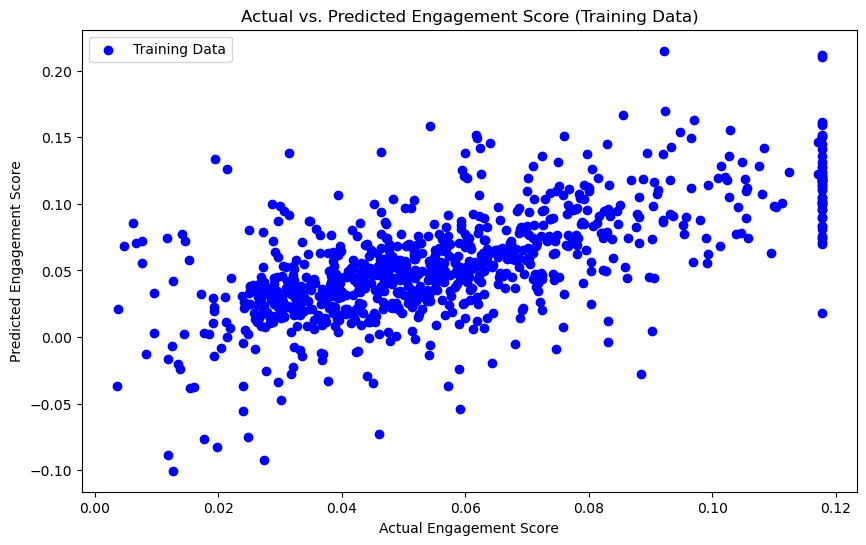

In [19]:
# Scatter plot for training data
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, color='blue', label='Training Data')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.title('Actual vs. Predicted Engagement Score (Training Data)')
plt.legend()
plt.show()

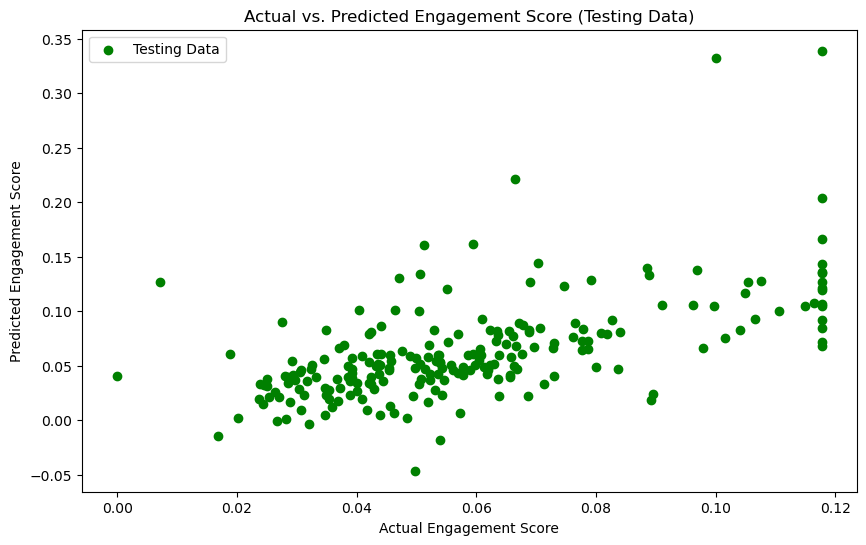

In [20]:
# Scatter plot for testing data
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='green', label='Testing Data')
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.title('Actual vs. Predicted Engagement Score (Testing Data)')
plt.legend()
plt.show()

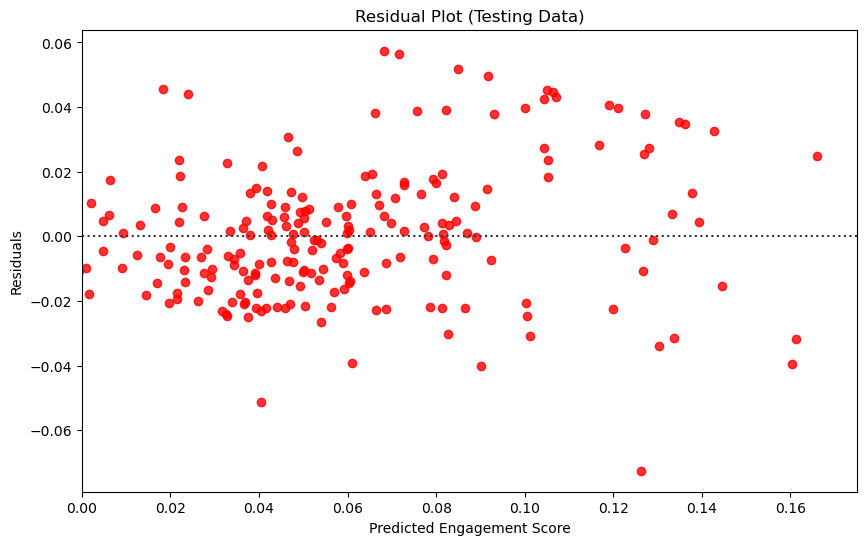

In [23]:
# Residual plot for testing data
residuals_test = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.residplot(y_test_pred, residuals_test, color='red')
plt.xlabel('Predicted Engagement Score')
plt.ylabel('Residuals')
plt.title('Residual Plot (Testing Data)')
plt.xlim(0, 0.175)  # Adjust the x-axis limits as needed
plt.show()


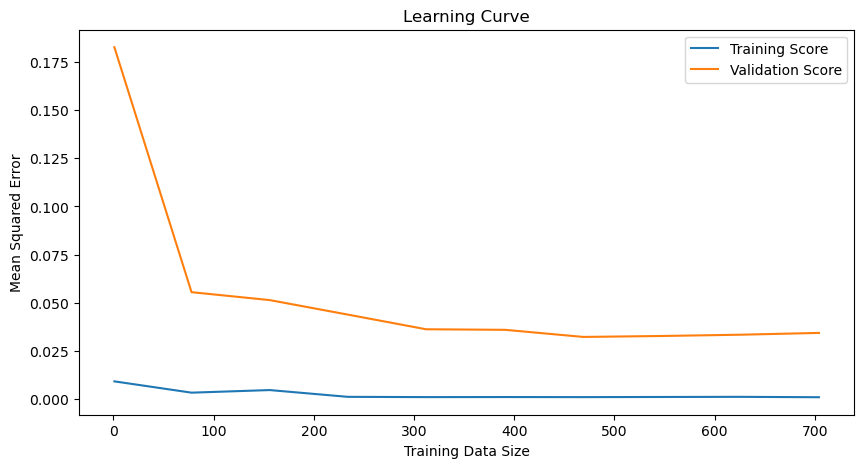

In [24]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Create learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5, train_sizes=np.linspace(0.000001, 1, 10),
    scoring='neg_mean_squared_error'
)

# Calculate mean squared errors
train_errors = -train_scores
test_errors = -test_scores

# Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(train_sizes, np.mean(train_errors, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_errors, axis=1), label='Validation Score')
plt.xlabel('Training Data Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

##  XGBRegressor

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor


In [17]:
import numpy as np

missing_values = np.isnan(y_train)  # Check for NaN values
print("Number of missing values:", np.sum(missing_values))



Number of missing values: 0


In [18]:
# Initialize the XGBoost regressor
model = XGBRegressor()

# Train the model on the training data
model.fit(X_train_scaled, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...)

In [19]:
# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Calculate Mean Squared Error (MSE) to evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


Mean Squared Error: 1.1912632134964598e-05


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Calculate Mean Squared Error (MSE) to evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")


Mean Squared Error: 1.1912632134964598e-05
Root Mean Squared Error: 0.0034514681129867906
Mean Absolute Error: 0.002008383642961417


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Assuming you have trained your XGBoost model and obtained predictions
y_train_pred = model.predict(X_train_scaled)

# Calculate Mean Squared Error (MSE) for training data
mse_train = mean_squared_error(y_train, y_train_pred)

# Calculate RMSE for training data
rmse_train = np.sqrt(mse_train)

# Calculate MAE for training data
mae_train = mean_absolute_error(y_train, y_train_pred)

print("Mean Squared Error (Train):", mse_train)
print("Root Mean Squared Error (Train):", rmse_train)
print("Mean Absolute Error (Train):", mae_train)


Mean Squared Error (Train): 4.919803260557441e-07
Root Mean Squared Error (Train): 0.0007014130923042028
Mean Absolute Error (Train): 0.0005175764128670042


In [22]:
# Assuming you have trained your XGBoost model and obtained predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

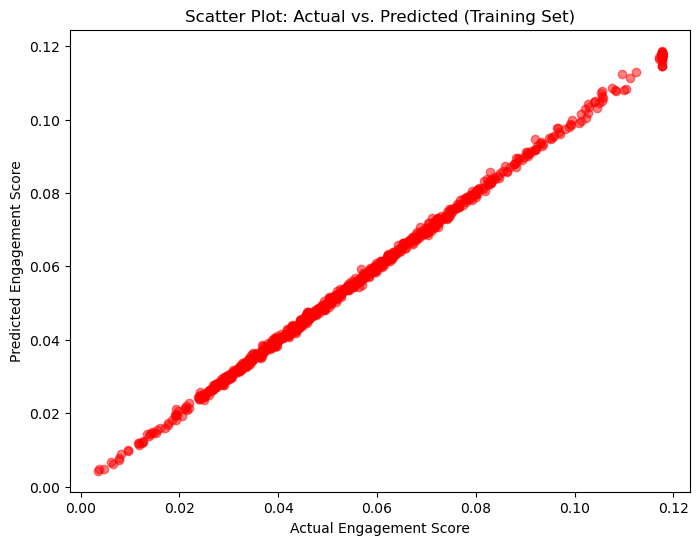

In [23]:
# Scatter Plot: Actual vs. Predicted for Training Set
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, color='red', alpha=0.5)
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.title('Scatter Plot: Actual vs. Predicted (Training Set)')
plt.show()

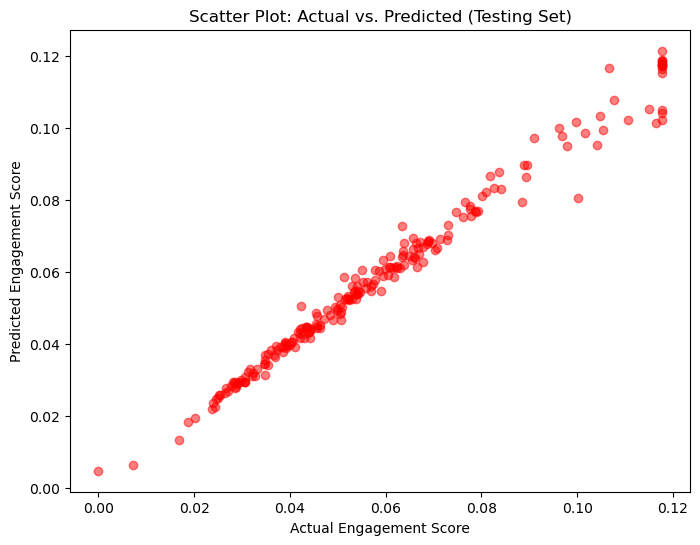

In [24]:
# Scatter Plot: Actual vs. Predicted for Testing Set
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='red', alpha=0.5)
plt.xlabel('Actual Engagement Score')
plt.ylabel('Predicted Engagement Score')
plt.title('Scatter Plot: Actual vs. Predicted (Testing Set)')
plt.show()

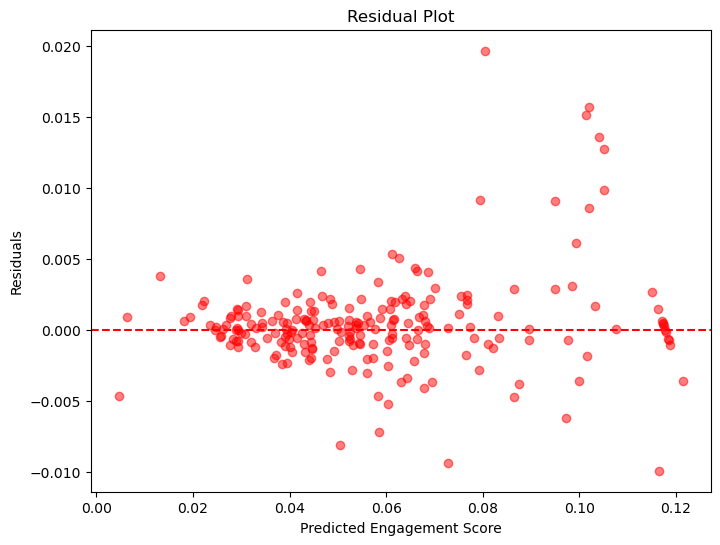

In [28]:
# Residual Plot for Testing Set
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, color='red', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Engagement Score')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()



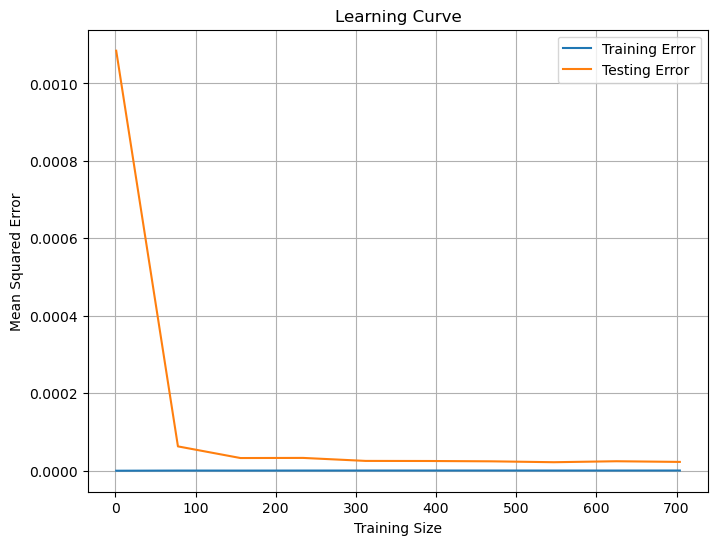

In [28]:
from sklearn.model_selection import learning_curve

# Define the training data sizes you want to use
train_sizes = np.linspace(0.000001, 1.0, 10)

# Create learning curve and obtain training and testing scores
train_sizes, train_scores, test_scores = learning_curve(
    XGBRegressor(), X_train_scaled, y_train, cv=5, train_sizes=train_sizes, scoring='neg_mean_squared_error'
)

# Calculate mean for training and testing scores
train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

# Step 7: Create a learning curve plot without shading
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Error')
plt.plot(train_sizes, test_scores_mean, label='Testing Error')
plt.xlabel('Training Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)

plt.show()

